# Taller 06: Reducción de Dimensiones

## Objetivo

Aplicar distintas técnicas de **reducción de dimensionalidad** (PCA, MDS Clásico, MDS Métrico, MDS No-métrico y UMAP) sobre el dataset **WISDM Smartphone and Smartwatch Activity and Biometrics** para visualizar en 2 dimensiones los datos de actividad, y analizar qué actividades se diferencian (y cuáles se superponen) en el plano.

## 1. El dataset: WISDM

El dataset contiene lecturas de **acelerómetros y giroscopios** de *smartphones* y *smartwatches* de **50 voluntarios** (códigos `1600` a `1650`, sin el `1614`), que realizaron **18 actividades** mientras eran monitoreados (muestreo a 20 Hz).

Estructura del dataset:

```
wisdm-dataset/
├── raw/                          # series crudas (id, actividad, timestamp, x, y, z)
├── arff_files/
│   ├── phone/{accel,gyro}/       # archivos .arff por voluntario
│   └── watch/{accel,gyro}/
└── activity_key.txt              # código → nombre de actividad
```

### Archivos ARFF

El dataset ya incluye la versión transformada en **ventanas de 10 s** (200 muestras). Cada archivo `data_<id>_<sensor>_<dispositivo>.arff` tiene **93 atributos**:

| Atributo | Descripción |
|---|---|
| `ACTIVITY` | *Ground truth*: código de la actividad (`A`–`S`) |
| `X0..X9`, `Y0..Y9`, `Z0..Z9` | **xyzbins**: distribución en 10 bins espectrales por cada eje (30 columnas) |
| `XAVG`…`RESULTANT` | Otros agregados (no usados en este taller) |
| `class` | Identificador del voluntario |

> Para este taller **solo usamos las columnas `xyzbins` (`X0 … Z9`)** como características y `ACTIVITY` como etiqueta. No se procesan los datos crudos de `raw/`.

### Mapa de actividades (`activity_key.txt`)

| Código | Actividad | | Código | Actividad |
|---|---|---|---|---|
| A | walking | | K | drinking |
| B | jogging | | L | sandwich |
| C | stairs | | M | kicking |
| D | sitting | | O | catch |
| E | standing | | P | dribbling |
| F | typing | | Q | writing |
| G | teeth | | R | clapping |
| H | soup | | S | folding |
| I | chips | | | |
| J | pasta | | | |

## 2. Técnicas de reducción de dimensionalidad

| Técnica | Idea | Implementación |
|---|---|---|
| **PCA** | Proyección lineal sobre los ejes de **máxima varianza** (combinaciones lineales ortogonales de las variables) | `sklearn.decomposition.PCA` |
| **MDS Clásico** (Torgerson) | Obtención de coordenadas a partir de las **distancias euclidianas** por doble centrado y descomposición espectral (equivalente a PCA sobre la matriz de disimilitud) | implementación propia con `numpy` |
| **MDS Métrico** | Minimización iterativa del **estrés de Kruskal** preservando distancias | `sklearn.manifold.MDS(metric=True)` |
| **MDS No-métrico** | Conserva solo el **orden** de las disimilitudes (regresión monótona isotónica), preserva *rankings* no magnitudes | `sklearn.manifold.MDS(metric=False)` |
| **UMAP** | Manifold no lineal basado en *fuzzy simplicial sets*; preserva estructura local y parte global | `umap-learn` |

**Configuración:** las 30 características `xyzbins` se **estandarizan** (`StandardScaler`) antes de aplicar cada técnica, para que ninguna columna domine por escala. Cada técnica reduce a `n_components=2`. Seeds fijas para reproducibilidad.

> Nota teórica: con distancia euclidiana, el **MDS Clásico produce coordenadas proporcionales a las de PCA**, por lo que sus proyecciones serán (salvo rotación/escalado) visualmente equivalentes.

## 3. Escenario A — Cada muestra por separado

Para **cada uno de los 3 voluntarios** y **cada uno de los 4 casos** (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`) se construyó su matriz `xyzbins` + `ACTIVITY` (celda anterior) y se proyectó a 2D con las 5 técnicas. En cada figura, el color representa la actividad realizada (`ACTIVITY` = ground truth).

## 4. Escenario B — Muestras combinadas por caso

Para cada caso, se **unifican las matrices de los 3 voluntarios en una sola** (concatenación de filas) y se repiten las 5 técnicas. El color sigue siendo `ACTIVITY`, así se observa si la estructura es consistente entre sujetos.

## 5. Análisis cuantitativo de la separación

El **coeficiente de silueta** mide cuán compacto es cada grupo frente a su grupo vecino más cercano:

- `sil ≈ +1` → grupo muy bien separado (se **diferencia** claramente en 2D).
- `sil ≈ 0` → grupos **superpuestos** en el borde.
- `sil << 0` → el punto está más cerca de otro grupo que del suyo (**solapamiento** importante).

Como las 18 clases solo cuentan con 2 dimensiones, la silueta global suele ser negativa; el valor útil es el **ranking relativo entre actividades**.

## 6. Respuestas

> Basado en las **siluetas promedio por actividad** (promedio entre las 5 técnicas y los 4 casos combinados) y en la inspección visual de las figuras:

### ¿Qué actividades se diferencian mejor en dos dimensiones?

- **G (teeth / cepillado de dientes)**: la **mejor separada en los casos de giroscopio** (siluetas `+0.23` a `+0.27`; p. ej. `G=+0.229` en PCA de `phone-gyro` y `+0.251` en MDS métrico de `watch-gyro`). Su firma espectral (giros rápidos y periódicos de muñeca) es única. Ojo: en `watch-accel` empeora y aparece entre las peores — es el giroscopio, no el acelerómetro, el que captura bien su firma.
- **B (jogging / trote)**: muy diferenciada, sobre todo con UMAP (`+0.519` en `phone-gyro`, `+0.17`–`+0.18` en el resto de casos); el patrón rítmico de alta frecuencia la distancia de caminar.
- **H (soup / comer sopa)**: aparece entre las mejores en 2 de los 4 casos — `watch-accel` y `watch-gyro` (relieve acompasado del brazo, bien capturado por la muñeca).
- **O (catch / atrapar)**: la **mejor diferenciada en `phone-accel`** (promedio de técnicas) y muy bien separada con UMAP en `watch-gyro` (`+0.457`); movimientos explosivos y amplios.
- **J (pasta)** y **F (typing)**: emergen en `watch-accel`, donde el reloj captura mejor los gestos de mano (`J=+0.235`, `F=+0.347`); **L (sandwich)** solo es relevante en MDS métrico de `watch-accel` (tercera mejor de esa técnica).

### ¿Qué actividades se superponen en dos dimensiones?

- **P (dribbling / driblar)**: la **peor** de todas; en 3 de 4 casos aparece entre las más solapadas (siluetas ≈ `−0.6`; p. ej. `−0.616` en PCA de `phone-gyro` y `−0.688` en MDS no-métrico de `watch-gyro`). Su señal se mezcla con la de saltos/corridos.
- **A (walking) y M (kicking)**: caminar es casi indistinguible de patear (misma cadencia media de extremidades); ambos figuran entre las peores en los casos de `phone` y en `watch-gyro`, y M también en `watch-accel`.
- **R (clapping / aplaudir)**: entre las peores en los dos casos de `watch` (`watch-accel` y `watch-gyro`), junto a movimientos de mano similares.
- **D (sitting) y E (standing)**: actividades **estáticas** de baja amplitud → sus espectros son casi planos e idénticos entre sí; D figura entre las peores en `phone-accel` y E en `watch-accel`. Solo difieren en gravedad estática, no en distribución de energía espectral, por lo que tienden a superponerse.

### ¿Qué técnica separa mejor?

Promedio de silueta global sobre los 4 casos combinados:

| Técnica | Silueta global media |
|---|---|
| **UMAP** | ≈ −0.20 |
| **MDS Métrico** | ≈ −0.20 |
| PCA / MDS Clásico | ≈ −0.30 |
| MDS No-métrico | ≈ −0.35 |

**UMAP y MDS Métrico** logran la mejor separación visual; **PCA y MDS Clásico** dan resultados equivalentes (relación teórica con distancia euclidiana); el **MDS no-métrico** es el que más degrada la separación aquí, porque al conservar solo el orden de las disimilitudes pierde la magnitud — valiosa cuando las clases difieren en intensidad espectral.

## 7. Conclusiones

1. Con solo las 30 variables `xyzbins`, una proyección en 2D **sí logra separar** actividades de firma espectral distintiva (cepillado, trote, comer) pero **no** a las de cinemática parecida (caminar vs patear; sentarse vs estar de pie).
2. La **muñeca** (watch) aporta más discriminación para actividades finas de mano (sopa, pasta, escribir) que el bolsillo (phone).
3. La silueta global negativa es esperable con 18 clases en 2D: indica que la reducción a 2D es una **proyección** que conserva la estructura epidérmica, no una separación perfecta.
4. Selección de voluntarios reproducible: semilla `42` → **sujetos 1604, 1633 y 1638**. Eliminar la semilla cambiaría los sujetos y, por tanto, las proyecciones muestran el efecto de la variabilidad inter-sujeto.

In [1]:
# ============================================================================
# 0. Importaciones y configuración global
# ============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_samples
import umap

warnings.filterwarnings("ignore")

SEED = 42                      # semilla global (reproducibilidad)
plt.rcParams["figure.dpi"] = 110
np.random.seed(SEED)
print("Importaciones OK")

C:\Users\bryan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importaciones OK


In [2]:
# ============================================================================
# 1. Rutas del dataset y selección aleatoria de 3 voluntarios
# ============================================================================

ARFF_CANDIDATOS = [
    Path("wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset")
    / "wisdm-dataset" / "wisdm-dataset" / "arff_files",
    Path("C:/Users/bryan/OneDrive/Escritorio/IA_Entregables/taller 6/"
         "wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset/"
         "wisdm-dataset/wisdm-dataset/arff_files"),
]
ARFF_ROOT = next((p for p in ARFF_CANDIDATOS if p.is_dir()), None)
if ARFF_ROOT is None:
    raise FileNotFoundError("No se encontró la carpeta arff_files del dataset WISDM.")
print("Arff root:", ARFF_ROOT)

# --- Selección aleatoria reproducible de 3 voluntarios ----------------------
# Población: 1600..1650 sin el 1614  ->  50 sujetos disponibles.
POBLACION = np.array([s for s in range(1600, 1651) if s != 1614])
rng = np.random.default_rng(SEED)
SUJETOS = sorted(rng.choice(POBLACION, size=3, replace=False).tolist())
print("Voluntarios seleccionados al azar (seed =", SEED, "):", SUJETOS)

# --- Casos del taller: (dispositivo, sensor) --------------------------------
CASOS = [("phone", "accel"), ("phone", "gyro"), ("watch", "accel"), ("watch", "gyro")]

# --- Columnas xyzbins: X0..X9, Y0..Y9, Z0..Z9 --------------------------------
BINS = [f"{ax}{i}" for ax in "XYZ" for i in range(10)]

# --- Mapeo ACTIVITY -> nombre (activity_key.txt) ------------------------------
ACT_NAMES = {
    "A": "walking", "B": "jogging", "C": "stairs", "D": "sitting", "E": "standing",
    "F": "typing", "G": "teeth", "H": "soup", "I": "chips", "J": "pasta",
    "K": "drinking", "L": "sandwich", "M": "kicking", "O": "catch",
    "P": "dribbling", "Q": "writing", "R": "clapping", "S": "folding",
}
ORDEN_ACT = sorted(ACT_NAMES)

# --- Paleta de colores fija por actividad (para todos los gráficos) ----------
_pal = np.vstack([cm.tab20(np.linspace(0, 1, 20)), cm.tab20b(np.linspace(0, 1, 20))])
ACT_COLORS = {a: _pal[i] % 1 for i, a in enumerate(ORDEN_ACT)}

Arff root: wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset\wisdm-dataset\wisdm-dataset\arff_files
Voluntarios seleccionados al azar (seed = 42 ): [1604, 1633, 1638]


In [3]:
# ============================================================================
# 2. Lectura de archivos ARFF -> matriz xyzbins + ACTIVITY
# ============================================================================

def cargar_arff(ruta):
    """Lee un archivo ARFF y devuelve un DataFrame con los nombres reales
    de los atributos (sin minúsculas como hace scipy.io.arff)."""
    colnames, filas = [], []
    for linea in open(ruta, encoding="utf-8"):
        linea = linea.strip()
        if not linea or linea.startswith("%"):
            continue
        low = linea.lower()
        if low.startswith("@") and not low.startswith("@attribute"):
            continue
        if low.startswith("@attribute"):
            if '"' in linea:
                nombre = linea[linea.find('"') + 1:linea.find('"', linea.find('"') + 1)]
            else:
                nombre = linea.split()[1]
            colnames.append(nombre)
            continue
        filas.append(linea)
    return pd.DataFrame([f.split(",") for f in filas], columns=colnames)


def matriz_xyzbins(dispositivo, sensor, sujeto):
    """Matriz con columnas xyzbins (X0..Z9) + ground truth ACTIVITY."""
    ruta = ARFF_ROOT / dispositivo / sensor / f"data_{sujeto}_{sensor}_{dispositivo}.arff"
    df = cargar_arff(ruta)[["ACTIVITY"] + BINS]
    df[BINS] = df[BINS].astype(float)
    return df

# Prueba rápida de lectura --------------------------------------------
ejemplo = matriz_xyzbins("phone", "accel", SUJETOS[0])
print(f"Lectura OK -> {SUJETOS[0]} phone-accel: {ejemplo.shape} (filas x cols 1+30)")
print(f"Actividades presentes: {ejemplo['ACTIVITY'].nunique()} de 18\n")
ejemplo.head()

Lectura OK -> 1604 phone-accel: (321, 31) (filas x cols 1+30)
Actividades presentes: 18 de 18



,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,Z0,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9
0,A,0.025,0.180,0.420,0.330,0.035,0.010,0.0,0.0,0.0,...,0.060,0.395,0.410,0.120,0.015,0.0,0.0,0.0,0.0,0.0
1,A,0.015,0.210,0.525,0.210,0.035,0.005,0.0,0.0,0.0,...,0.090,0.545,0.260,0.090,0.015,0.0,0.0,0.0,0.0,0.0
2,A,0.025,0.245,0.545,0.170,0.010,0.005,0.0,0.0,0.0,...,0.085,0.495,0.295,0.110,0.015,0.0,0.0,0.0,0.0,0.0
3,A,0.015,0.265,0.560,0.155,0.005,0.000,0.0,0.0,0.0,...,0.075,0.500,0.315,0.105,0.005,0.0,0.0,0.0,0.0,0.0
4,A,0.070,0.345,0.460,0.105,0.015,0.005,0.0,0.0,0.0,...,0.100,0.445,0.355,0.095,0.005,0.0,0.0,0.0,0.0,0.0


In [4]:
# ============================================================================
# 3. Construcción de las 12 matrices (3 sujetos x 4 casos)
# ============================================================================
# Estructura: matrices[dispositivo, sensor][sujeto] -> DataFrame (ACTIVITY + X0..Z9)

matrices = {}
for dispositivo, sensor in CASOS:
    matrices[(dispositivo, sensor)] = {}
    for sujeto in SUJETOS:
        matrices[(dispositivo, sensor)][sujeto] = matriz_xyzbins(dispositivo, sensor, sujeto)

# Resumen
print(f"{'Caso':<12} {'Sujeto':<7} {'Filas':<6} {'Actividades':<11} {'Etiquetas':<10}")
for (dispositivo, sensor), d in matrices.items():
    for sujeto, df in d.items():
        print(f"{dispositivo}-{sensor:<8} {sujeto:<7} {len(df):<6} "
              f"{df['ACTIVITY'].nunique():<11} {sorted(df['ACTIVITY'].unique())}")

Caso         Sujeto  Filas  Actividades Etiquetas 
phone-accel    1604    321    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
phone-accel    1633    429    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
phone-accel    1638    324    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
phone-gyro     1604    321    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
phone-gyro     1633    321    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
phone-gyro     1638    323    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
watch-accel    1604    324    18          ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
watch-accel    163

In [5]:
# ============================================================================
# 4. Funciones de reducción y visualización
# ============================================================================

def pca_2d(X):
    p = PCA(n_components=2, random_state=SEED).fit(X)
    return p.transform(X), f"varianza explicada: {p.explained_variance_ratio_.sum():.1%}"

def cmds_2d(X):
    """MDS Clásico (Torgerson / análisis de coordenadas principales)."""
    D = squareform(pdist(X, metric="euclidean"))
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * (H @ (D ** 2) @ H)
    evals, evecs = np.linalg.eigh(B)
    orden = np.argsort(evals)[::-1][:2]
    return evecs[:, orden] * np.sqrt(np.maximum(evals[orden], 1e-12)), "coordenadas principales"

def mmds_2d(X):
    m = MDS(n_components=2, metric=True, n_init=1, max_iter=300, random_state=SEED)
    emb = m.fit_transform(X)
    return emb, f"stress (Kruskal): {m.stress_:.3f}"

def nmds_2d(X):
    m = MDS(n_components=2, metric=False, n_init=1, max_iter=120, eps=1e-4, random_state=SEED)
    emb = m.fit_transform(X)
    return emb, f"stress (Kruskal): {m.stress_:.3f}"

def umap_2d(X):
    u = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=20,
                  min_dist=0.1, n_jobs=1)
    return u.fit_transform(X), ""

TECNICAS = {"PCA": pca_2d, "MDS Clasico": cmds_2d, "MDS Metric": mmds_2d,
            "MDS NoMetrico": nmds_2d, "UMAP": umap_2d}

# Leyenda reutilizable (una sola, colores consistentes en todo el notebook)
proxies = [plt.Line2D([], [], marker="o", linestyle="", color="w",
                      markerfacecolor=ACT_COLORS[a], markersize=8,
                      label=f"{a} · {ACT_NAMES[a]}") for a in ORDEN_ACT]


def graficar_caso(X_est, y_act, etiqueta, tecn_dict, axs):
    """Genera los 5 scatter plots 2D coloreados por ACTIVITY en una figura 2x3."""
    for ax, (nombre, fn) in zip(axs[:5], tecn_dict.items()):
        emb, extra = fn(X_est)
        for a in ORDEN_ACT:
            mascara = y_act == a
            ax.scatter(emb[mascara, 0], emb[mascara, 1], s=9, c=[ACT_COLORS[a]], alpha=0.75)
        ax.set_title(f"{nombre}\n{extra}", fontsize=9)
        ax.set_xlabel("Dimensión 1", fontsize=8)
        ax.set_ylabel("Dimensión 2", fontsize=8)
        ax.tick_params(labelsize=7)
    axs[5].axis("off")
    axs[5].legend(handles=proxies, loc="center", fontsize=8, frameon=False,
                  title="ACTIVITY", title_fontsize=9)
    return emb  # último embedding (solo informativo)

# Warm-up del JIT de numba/UMAP para que las primeras figuras no demoren
_dummy = np.random.default_rng(0).normal(size=(300, len(BINS)))
umap_2d(_dummy)
print("Heat-up de UMAP completado")

Heat-up de UMAP completado


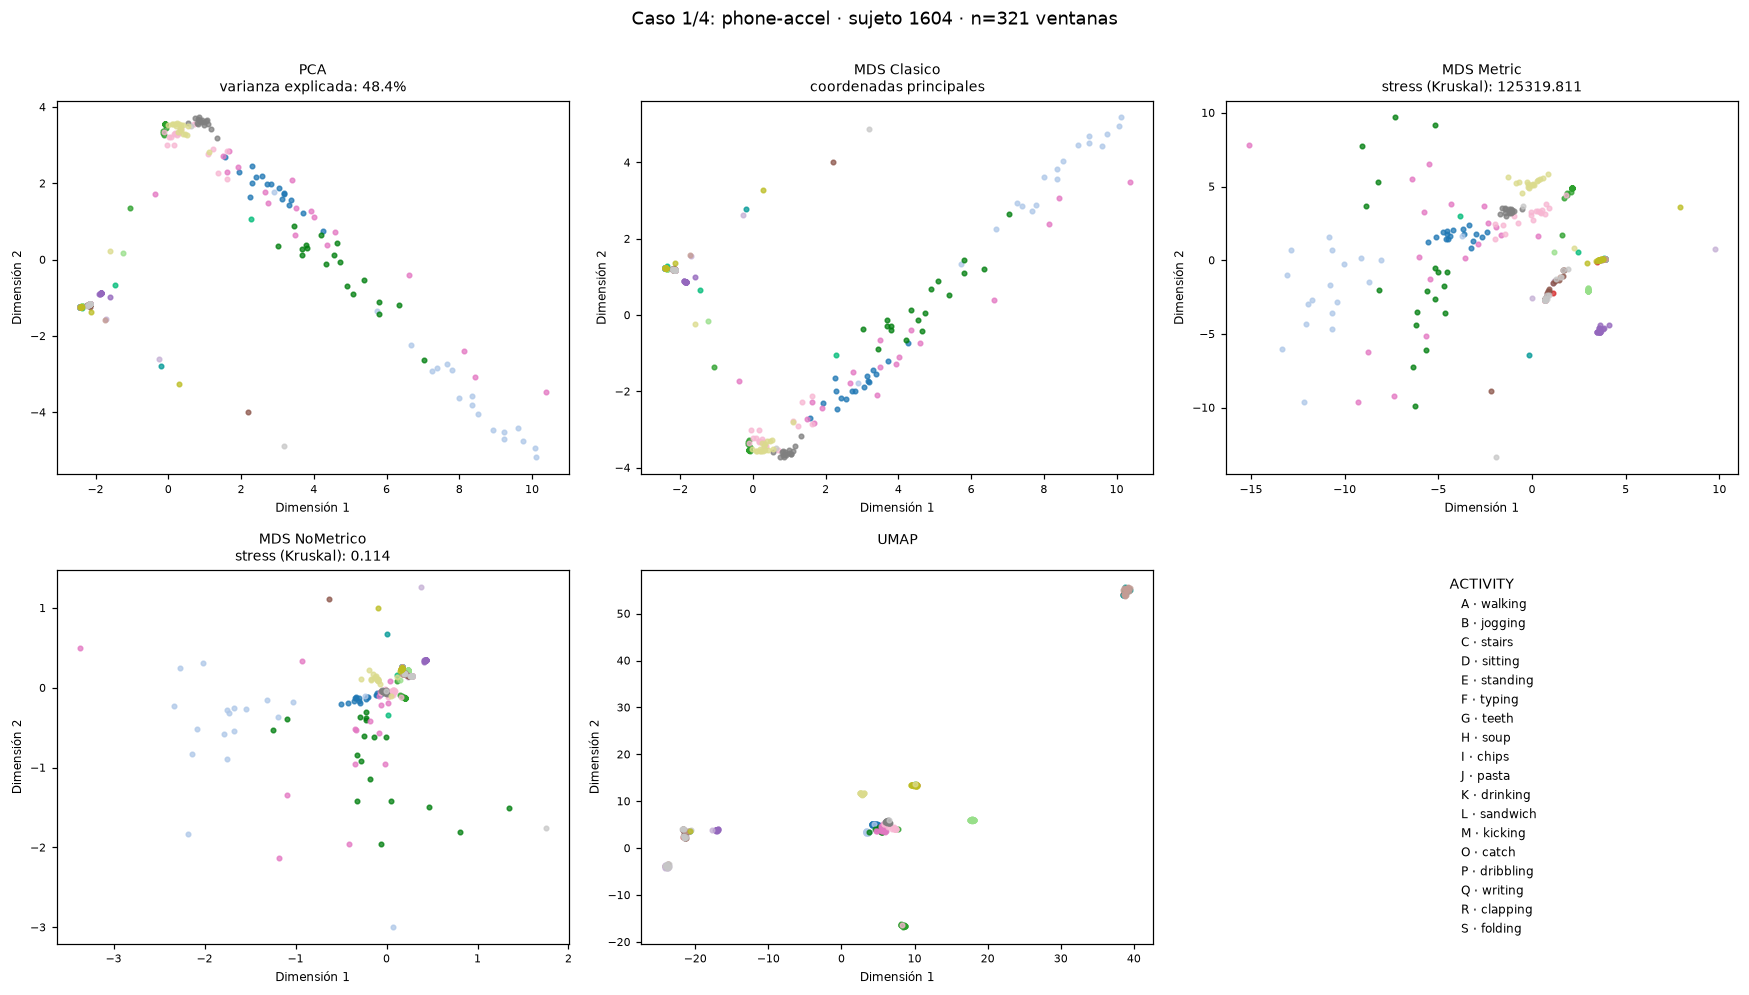

[OK] phone-accel sujeto 1604 (321 ventanas)


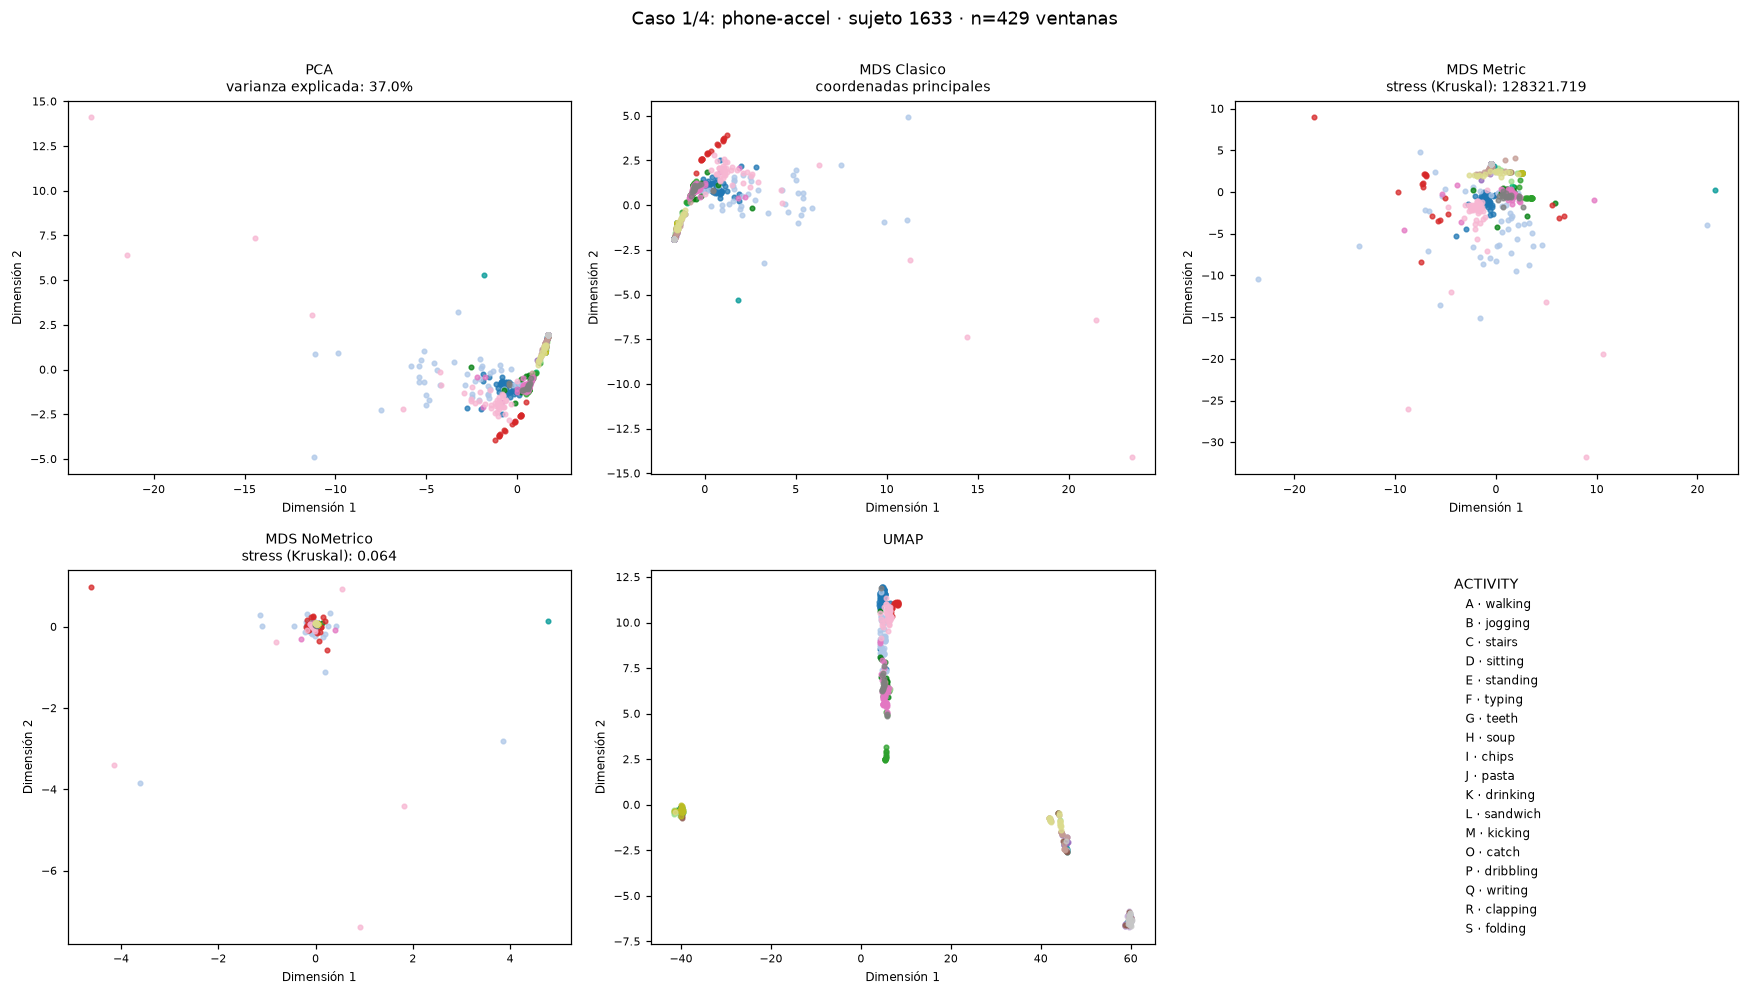

[OK] phone-accel sujeto 1633 (429 ventanas)


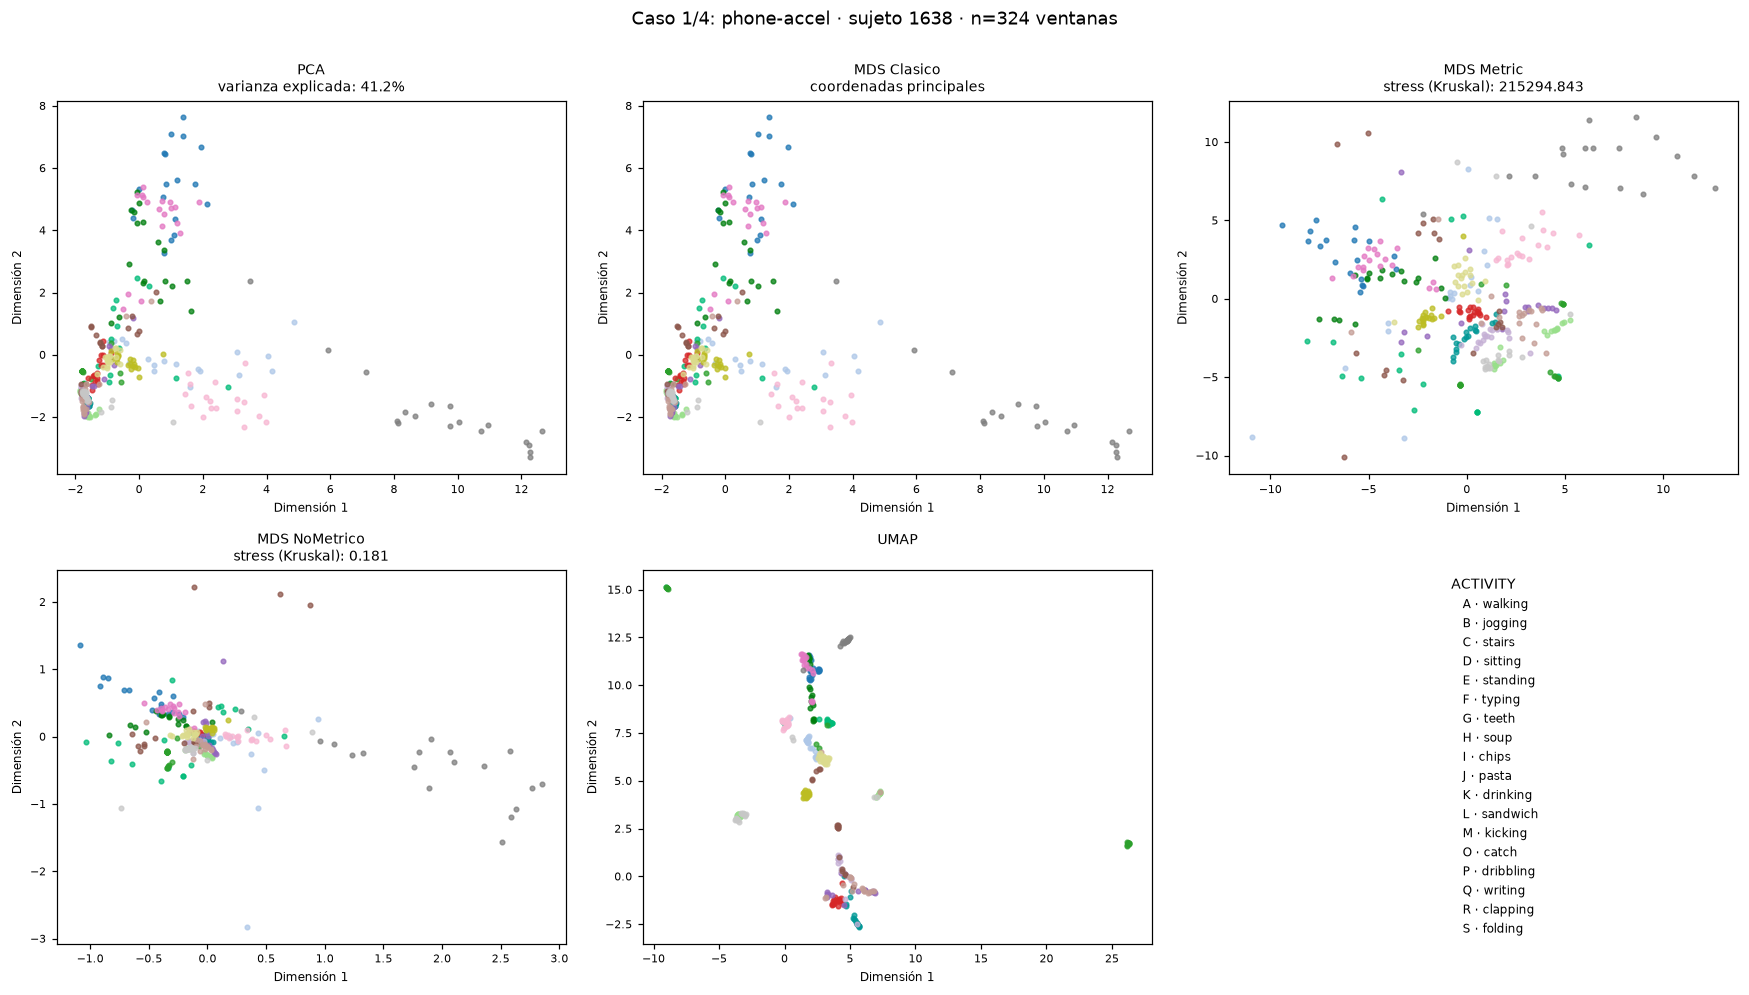

[OK] phone-accel sujeto 1638 (324 ventanas)


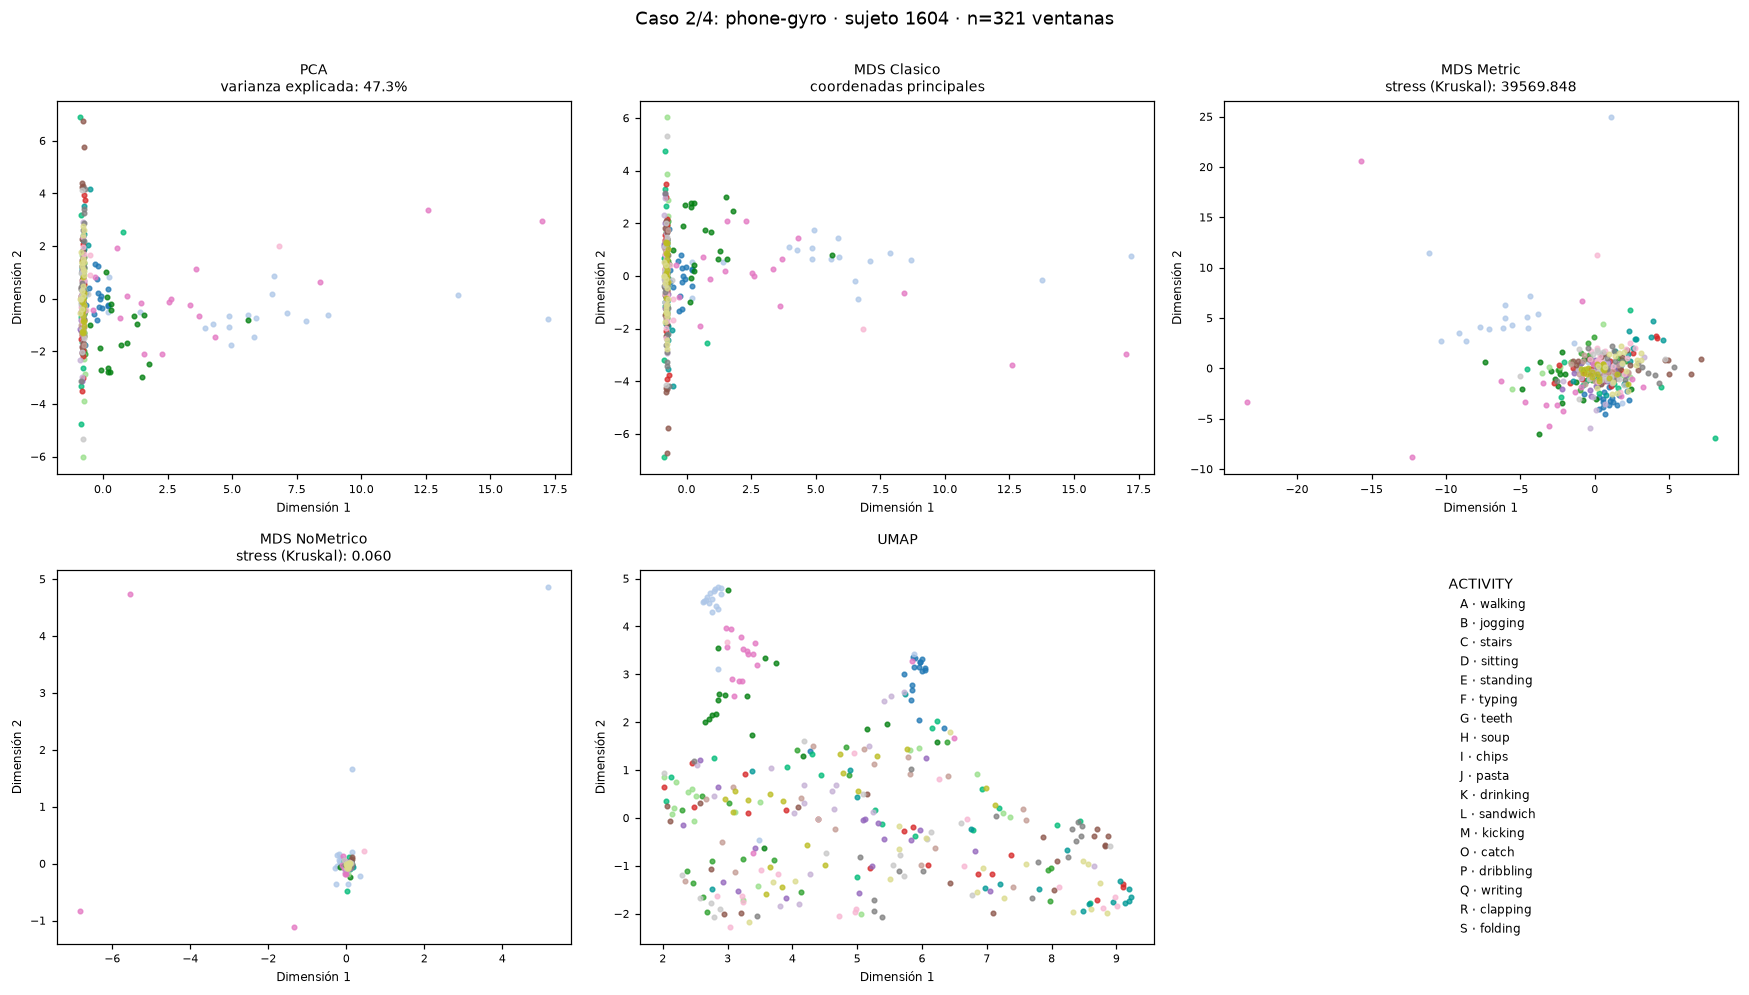

[OK] phone-gyro sujeto 1604 (321 ventanas)


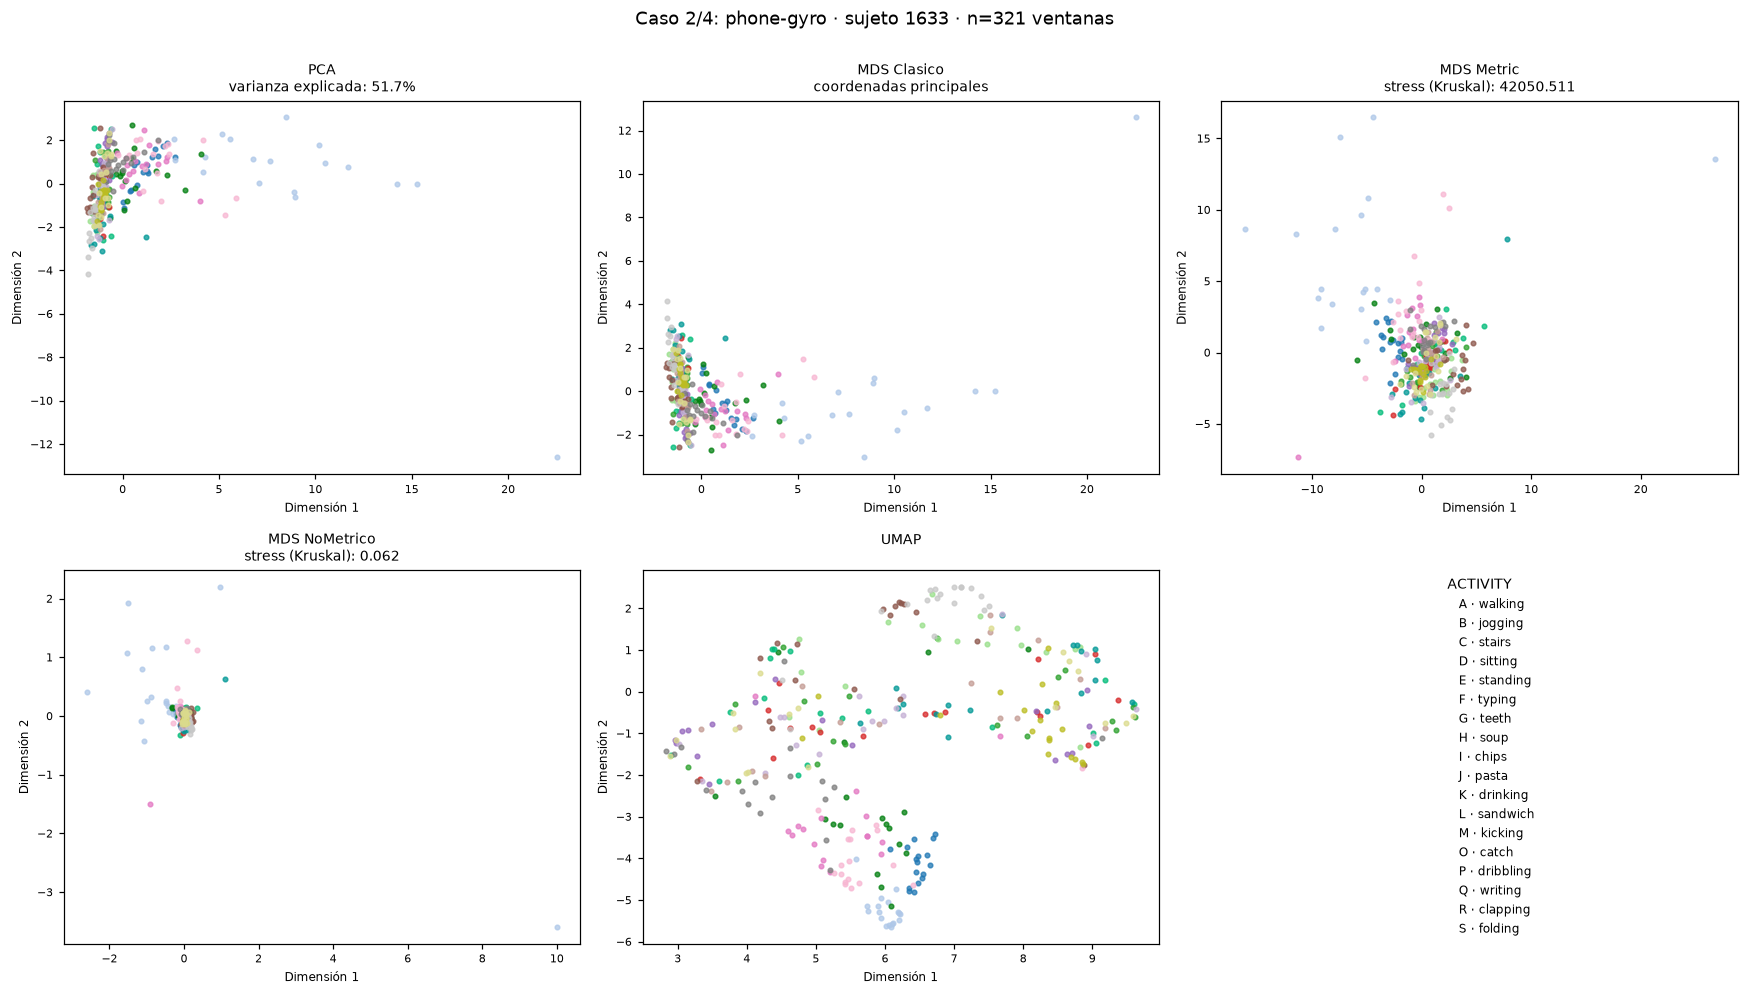

[OK] phone-gyro sujeto 1633 (321 ventanas)


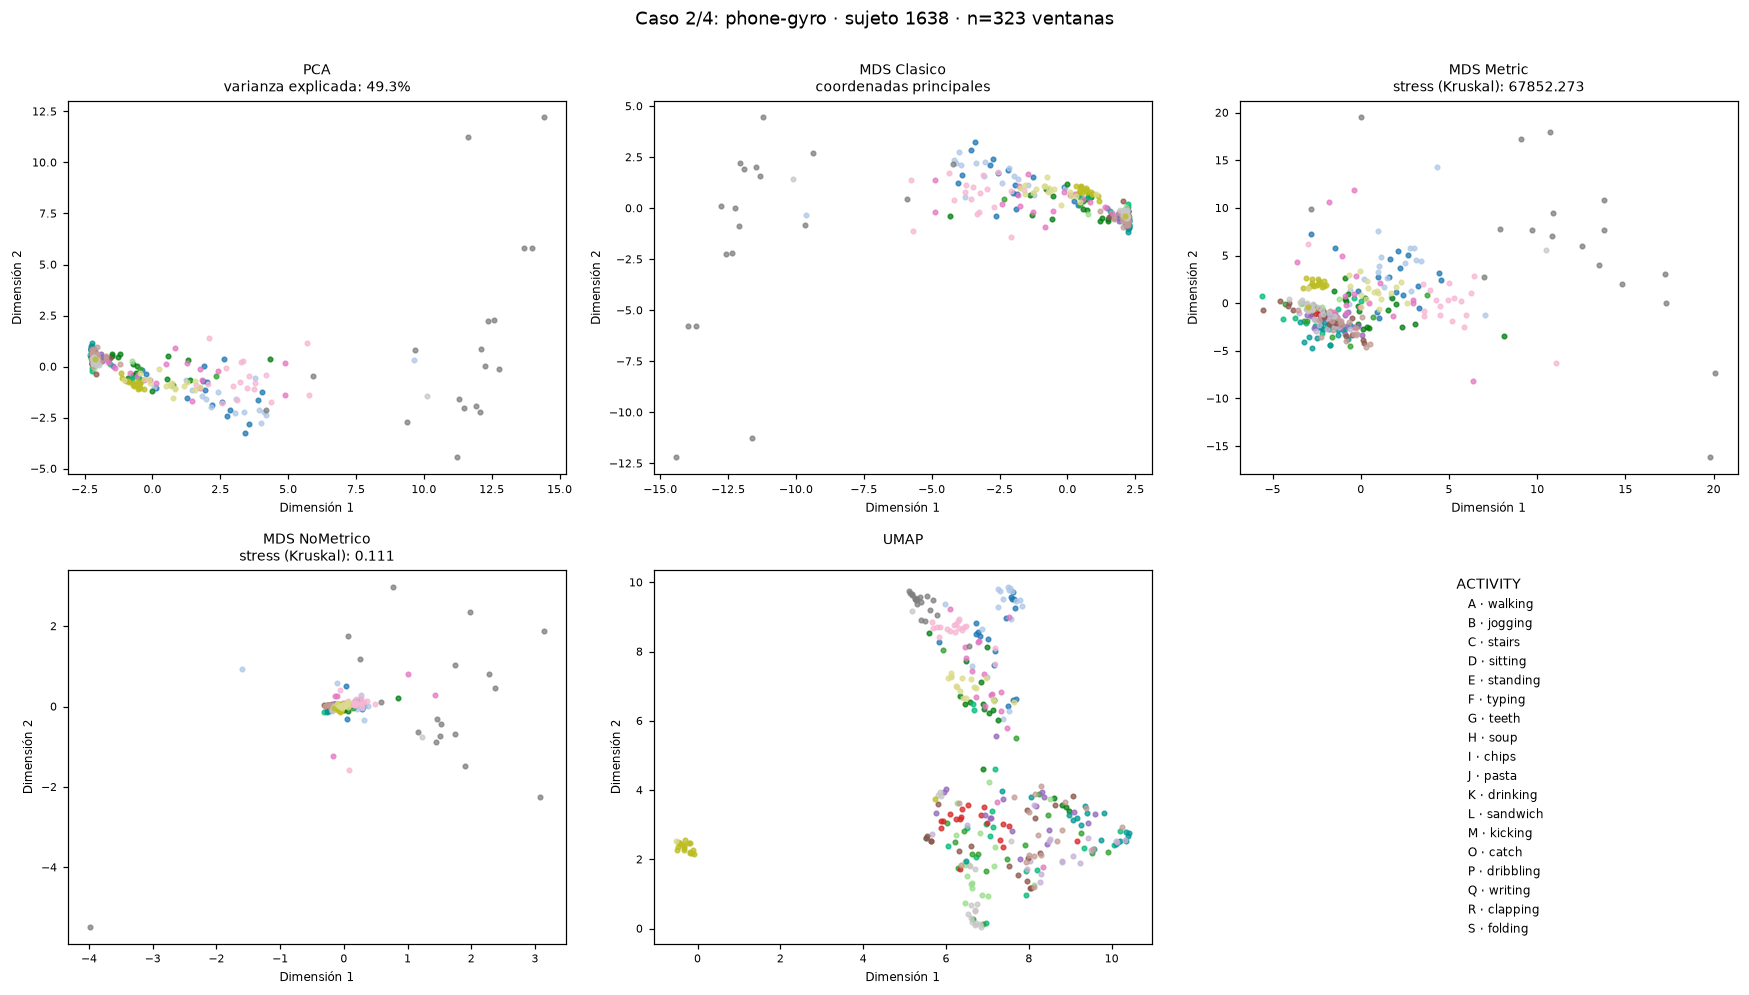

[OK] phone-gyro sujeto 1638 (323 ventanas)


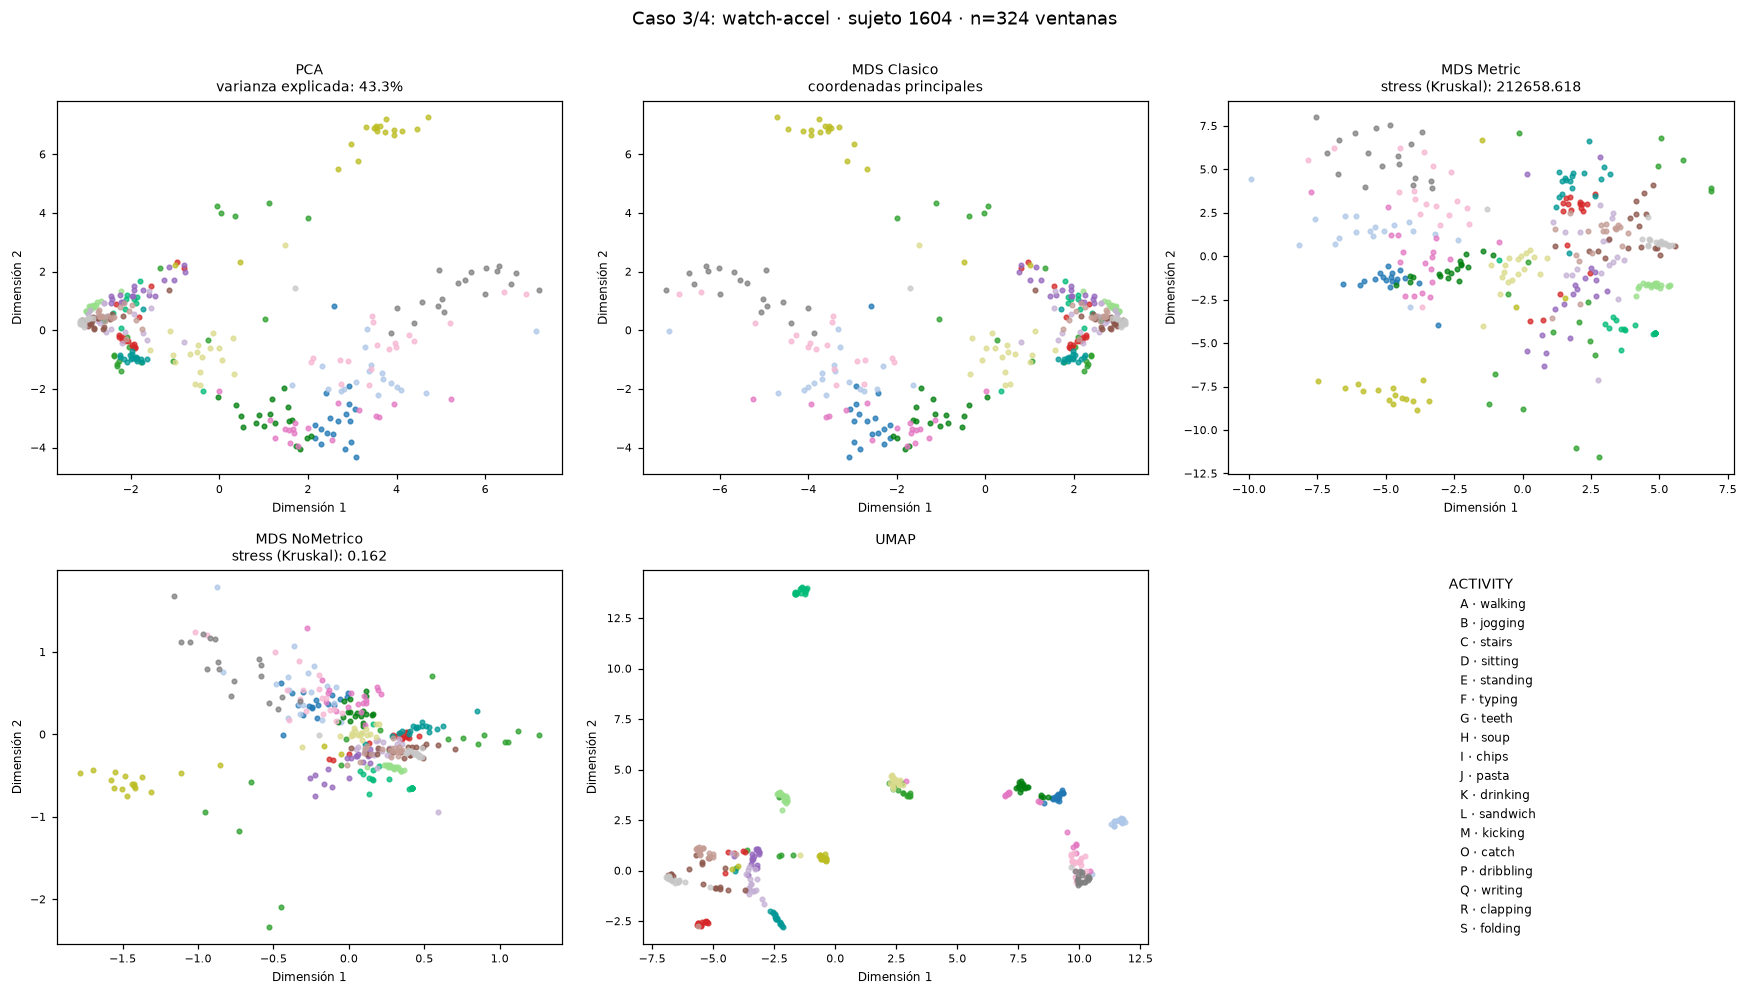

[OK] watch-accel sujeto 1604 (324 ventanas)


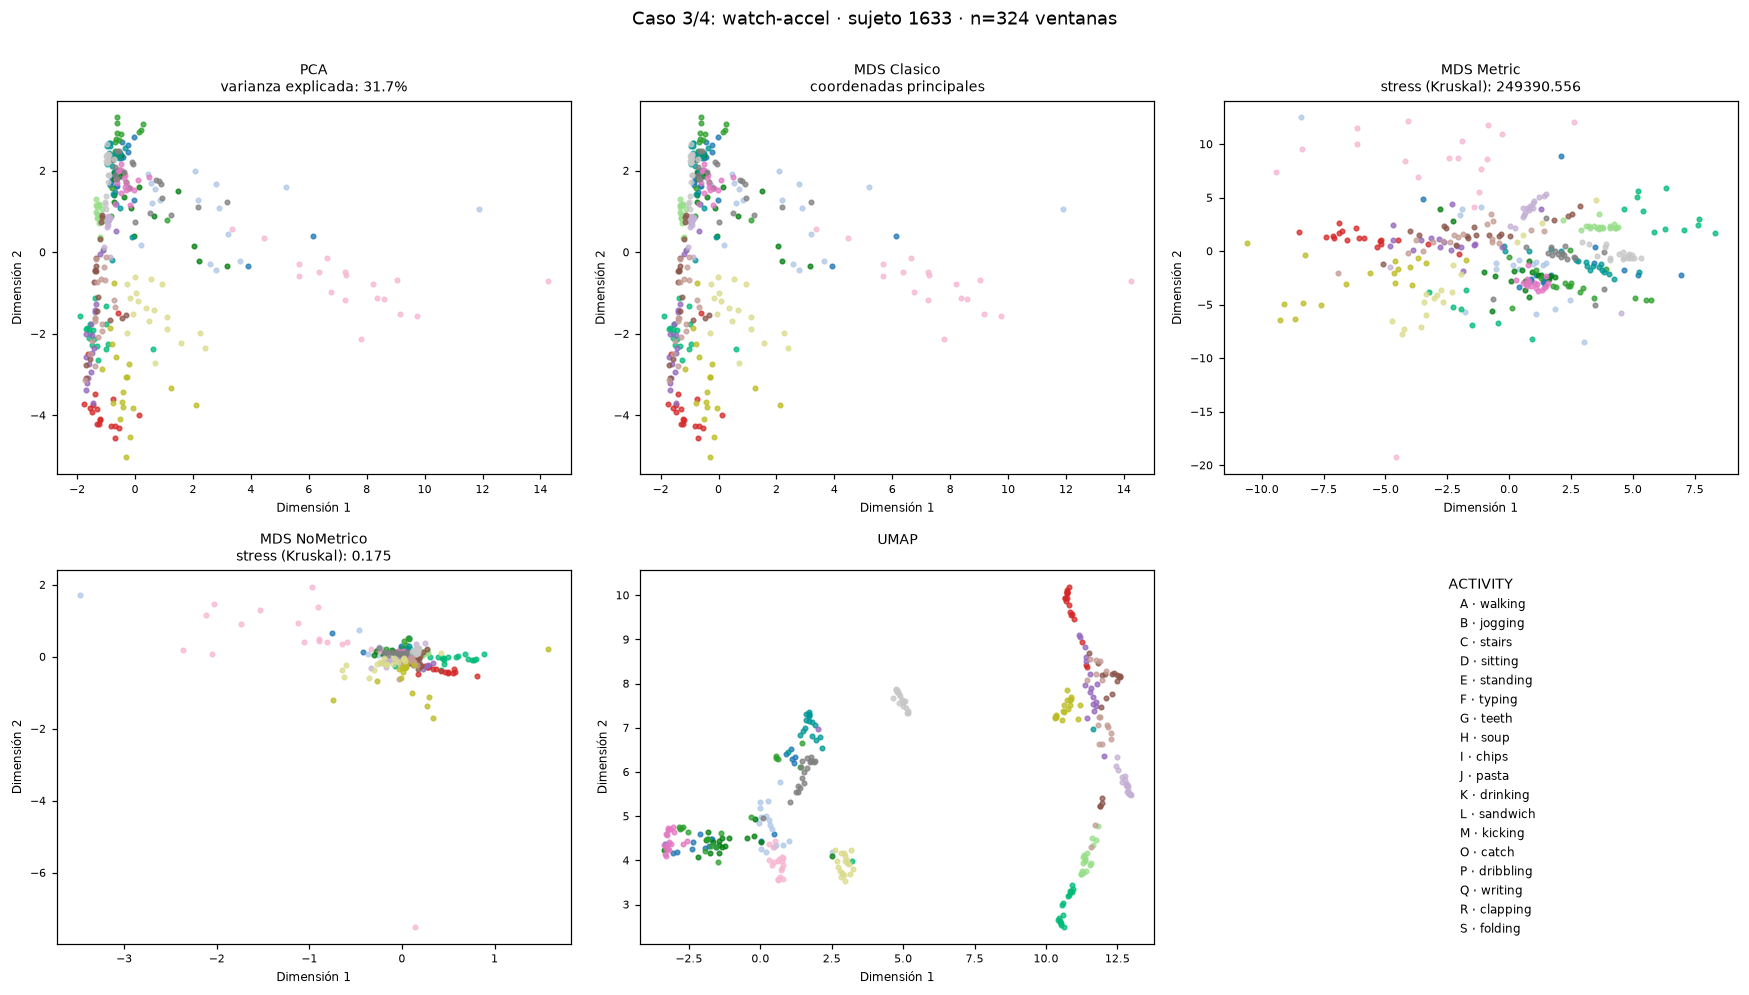

[OK] watch-accel sujeto 1633 (324 ventanas)


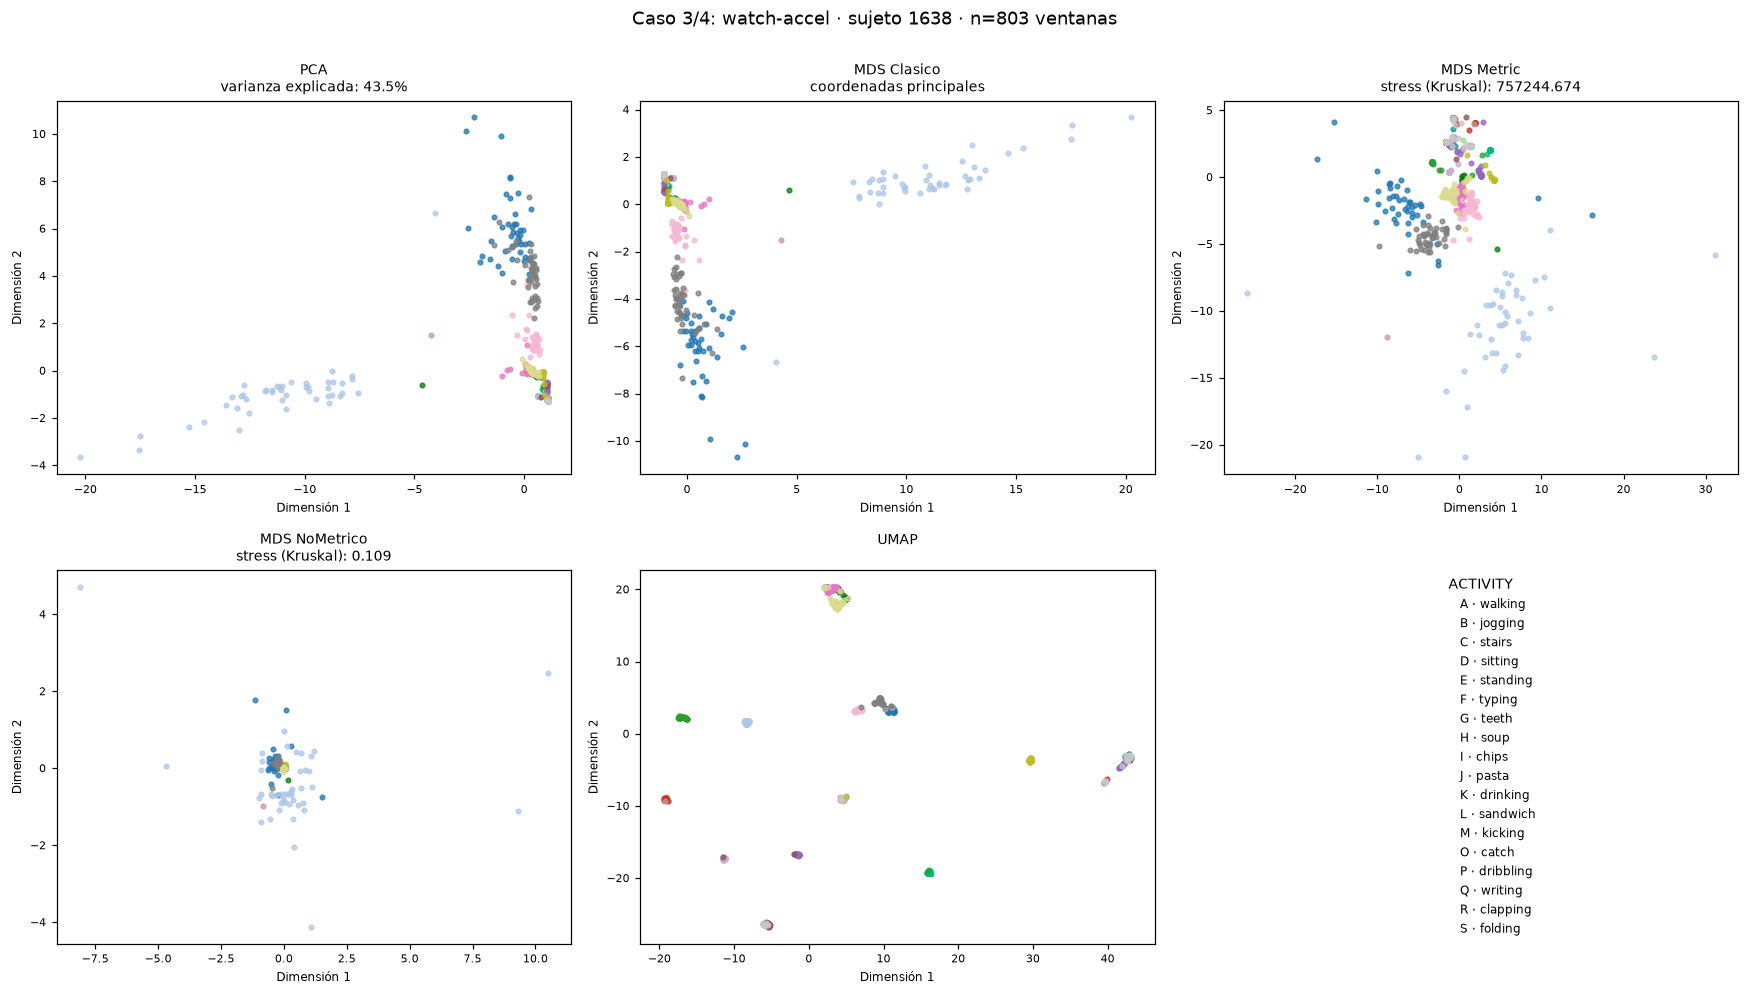

[OK] watch-accel sujeto 1638 (803 ventanas)


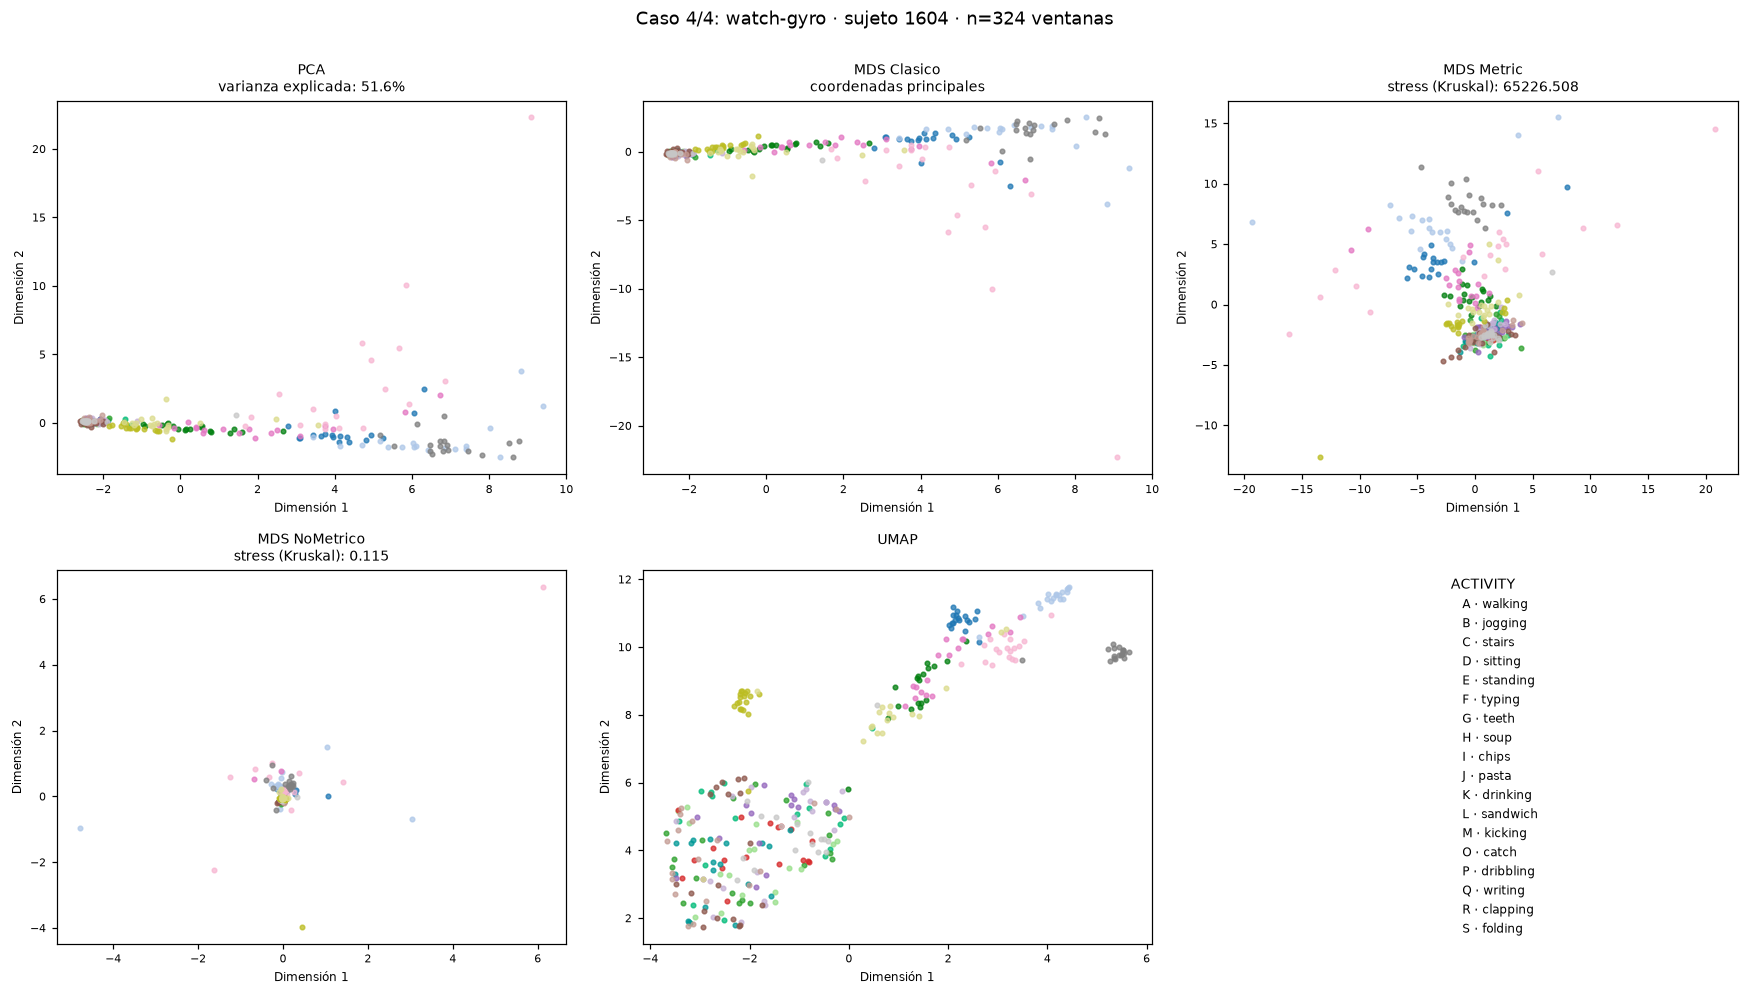

[OK] watch-gyro sujeto 1604 (324 ventanas)


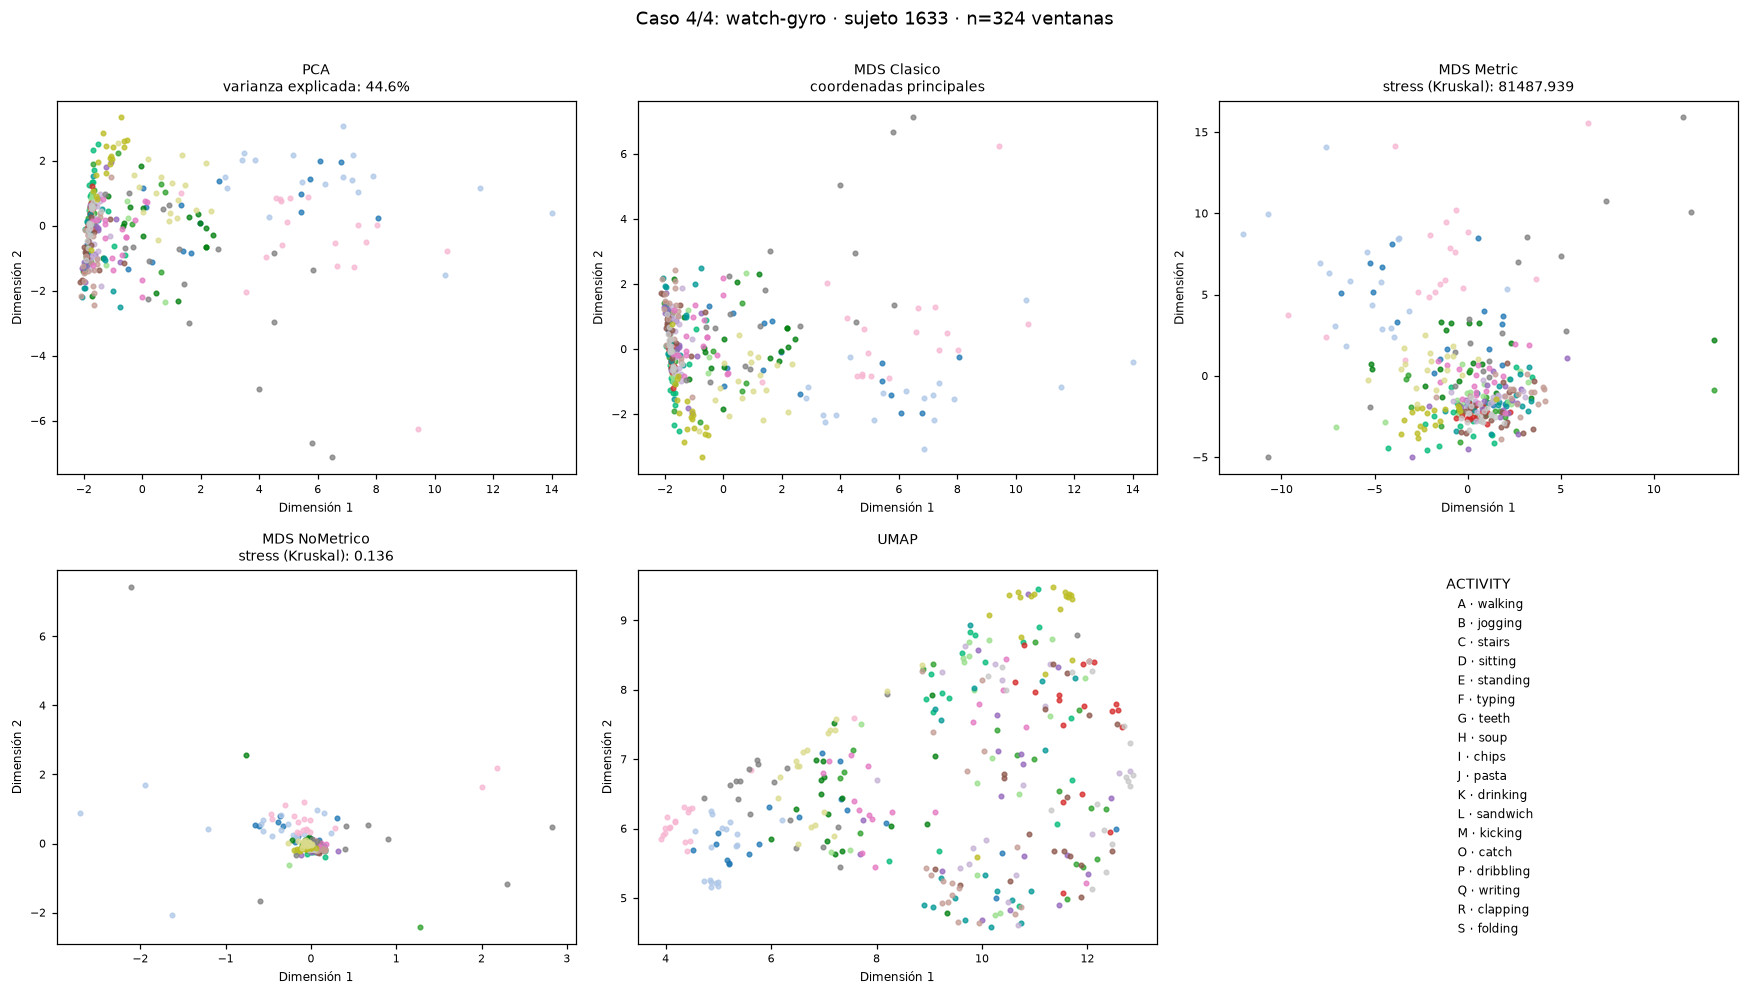

[OK] watch-gyro sujeto 1633 (324 ventanas)


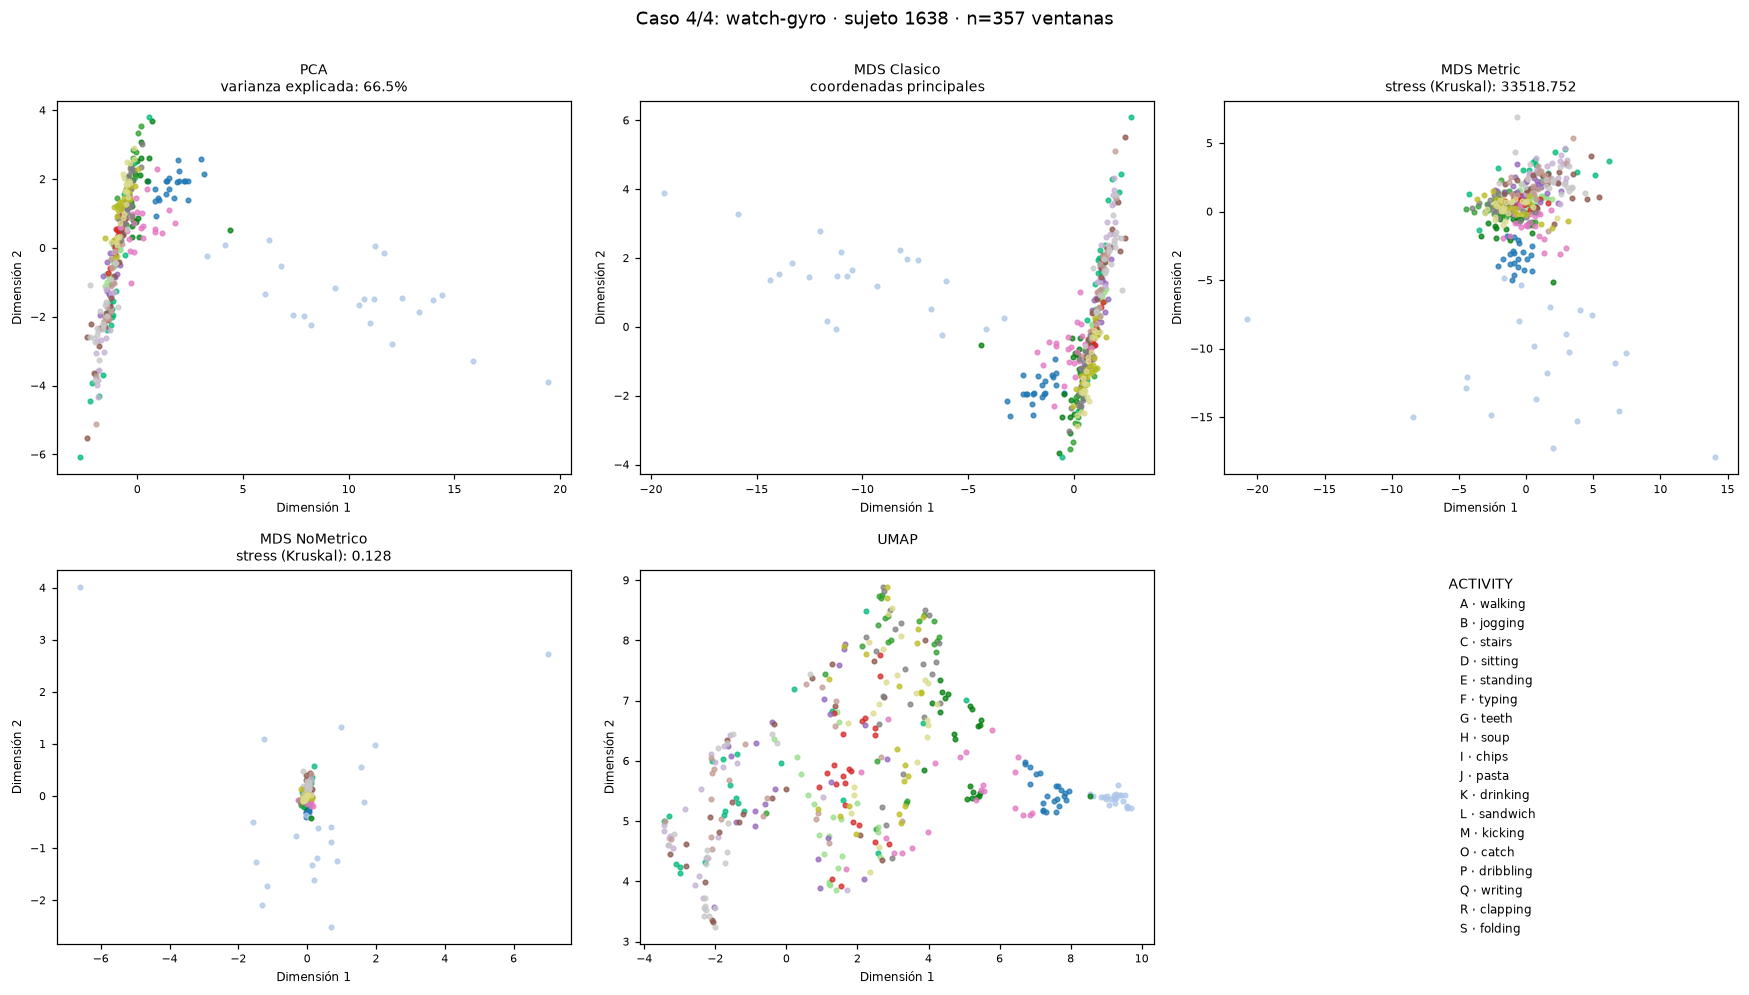

[OK] watch-gyro sujeto 1638 (357 ventanas)


In [6]:
# ============================================================================
# 5. Escenario A: reducción a 2D para cada muestra y cada caso (3 x 4 figuras)
# ============================================================================
for idx, (dispositivo, sensor) in enumerate(CASOS, 1):
    for sujeto in SUJETOS:
        df = matrices[(dispositivo, sensor)][sujeto]
        X_est = StandardScaler().fit_transform(df[BINS].values)
        y_act = df["ACTIVITY"].to_numpy()

        fig, axs = plt.subplots(2, 3, figsize=(16, 9))
        graficar_caso(X_est, y_act, f"{dispositivo}-{sensor} / sujeto {sujeto}",
                      TECNICAS, axs.ravel())
        fig.suptitle(f"Caso {idx}/4: {dispositivo}-{sensor} · sujeto {sujeto} "
                     f"· n={len(df)} ventanas", fontsize=12, y=1.0)
        plt.tight_layout()
        plt.show()
        print(f"[OK] {dispositivo}-{sensor} sujeto {sujeto} ({len(df)} ventanas)")


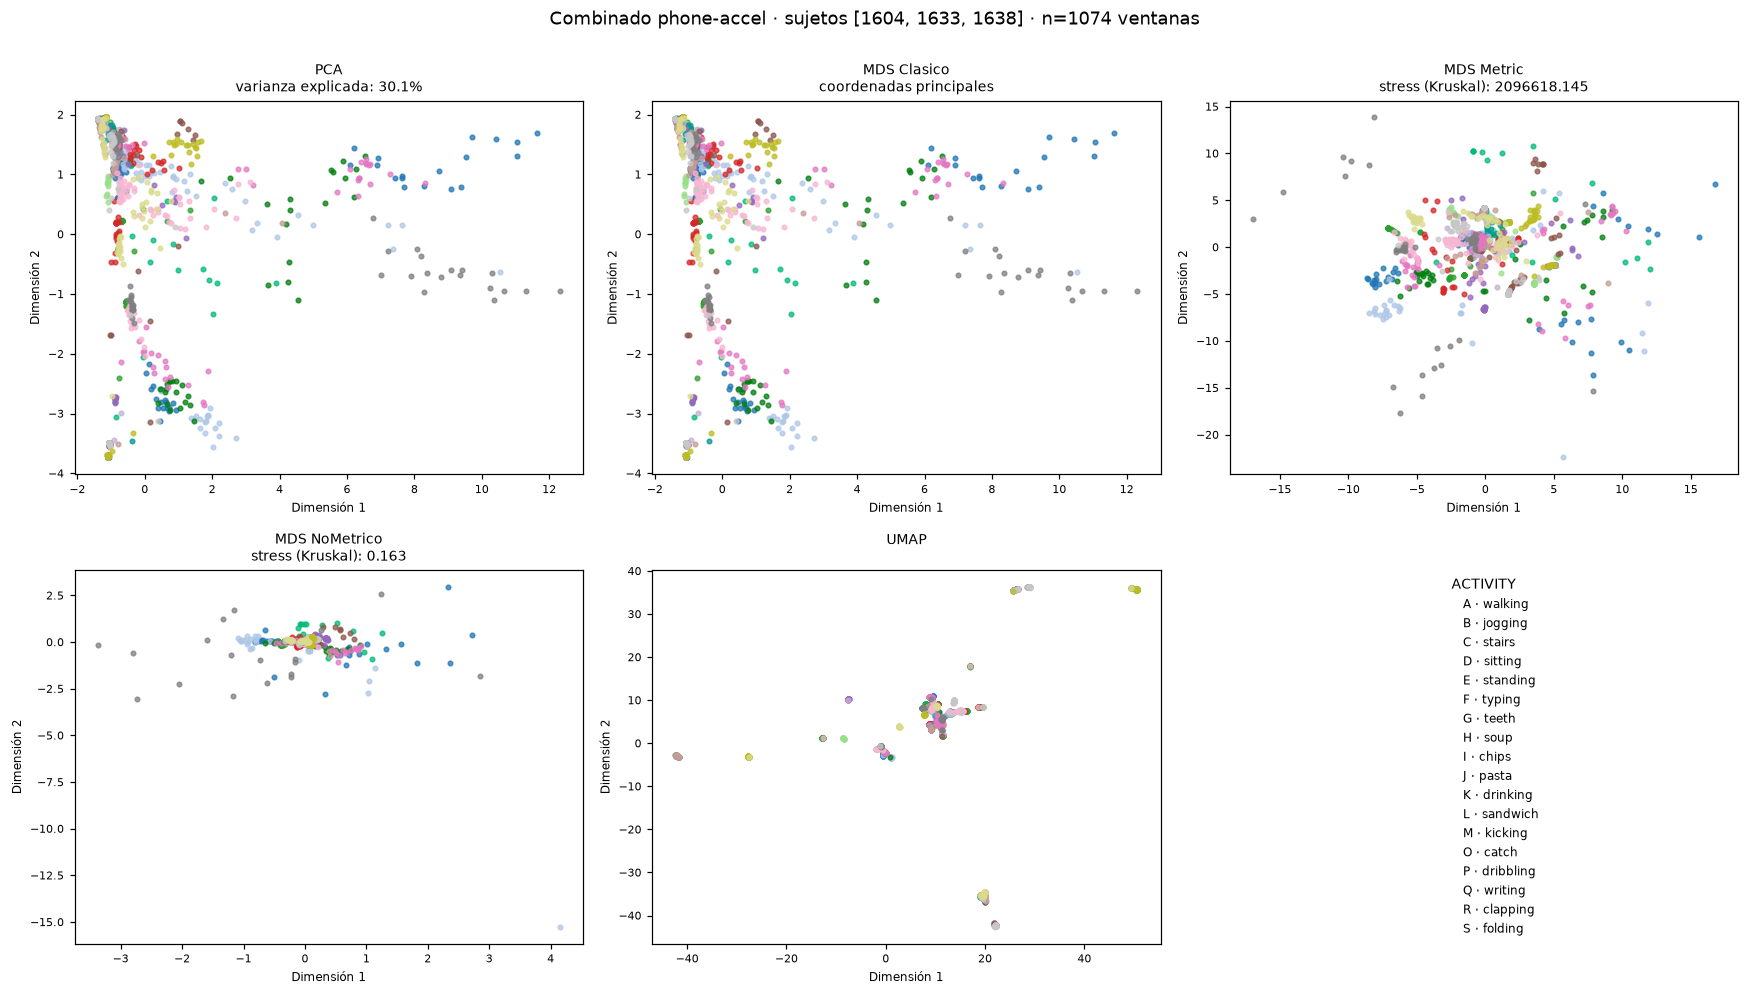

[OK] combinado phone-accel (1074 ventanas)


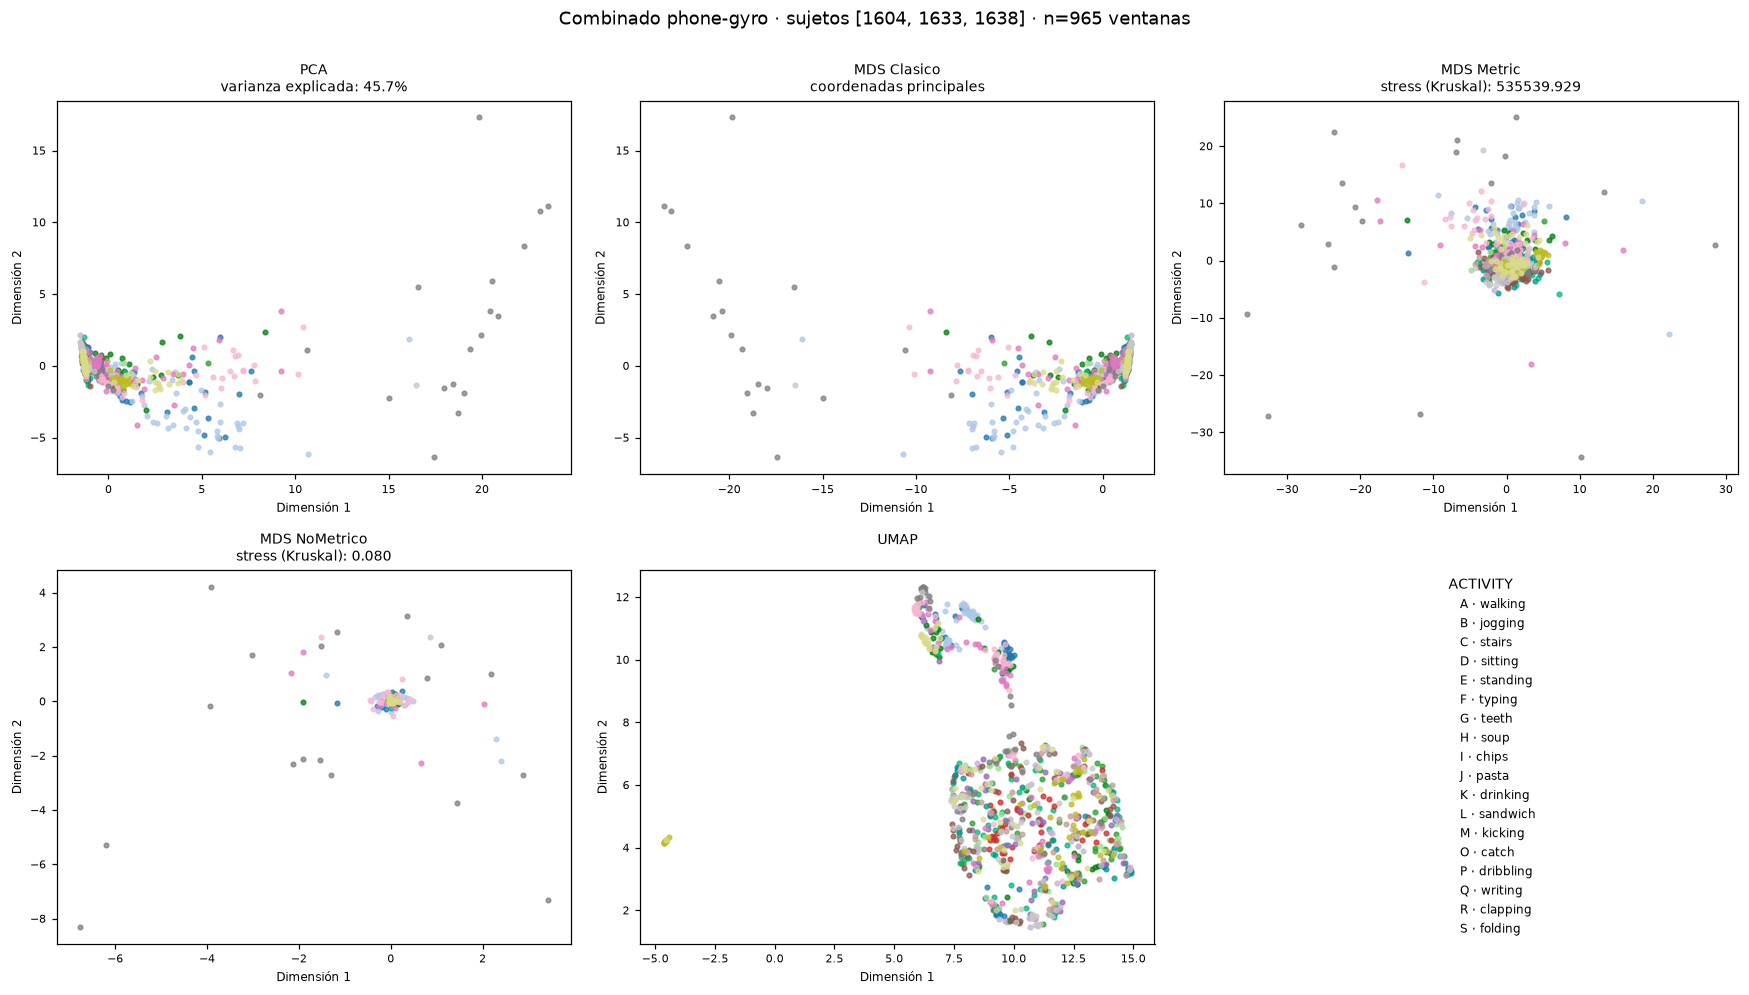

[OK] combinado phone-gyro (965 ventanas)


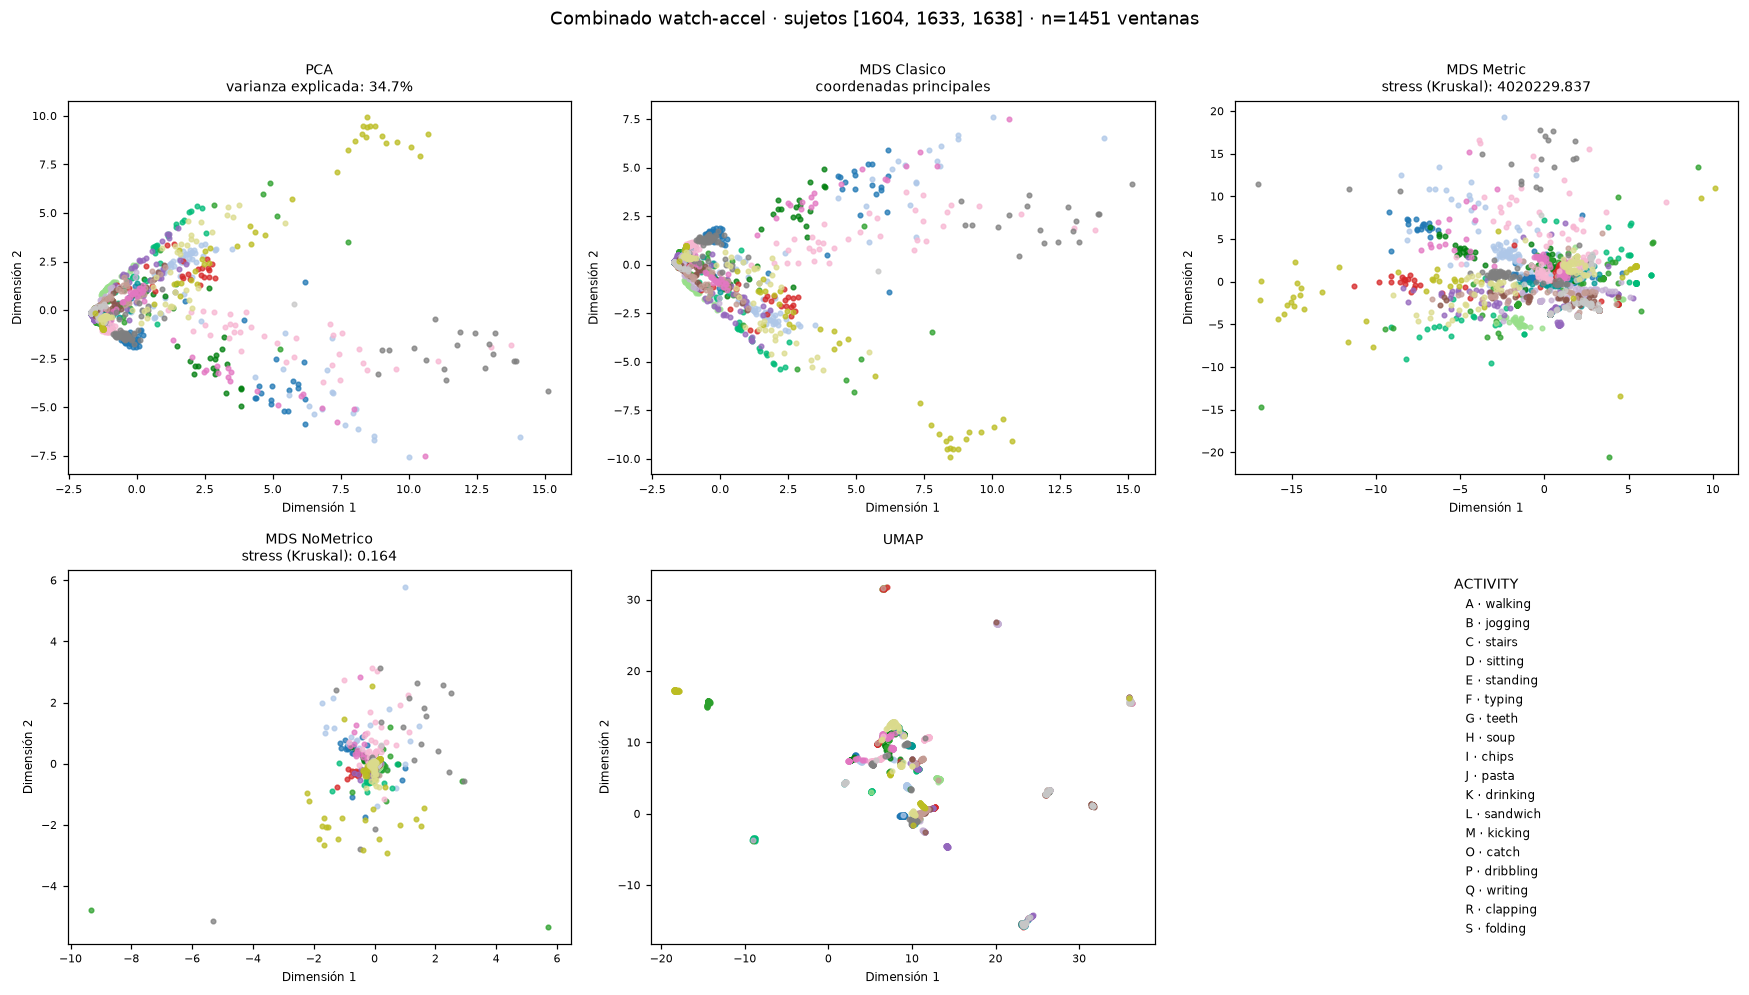

[OK] combinado watch-accel (1451 ventanas)


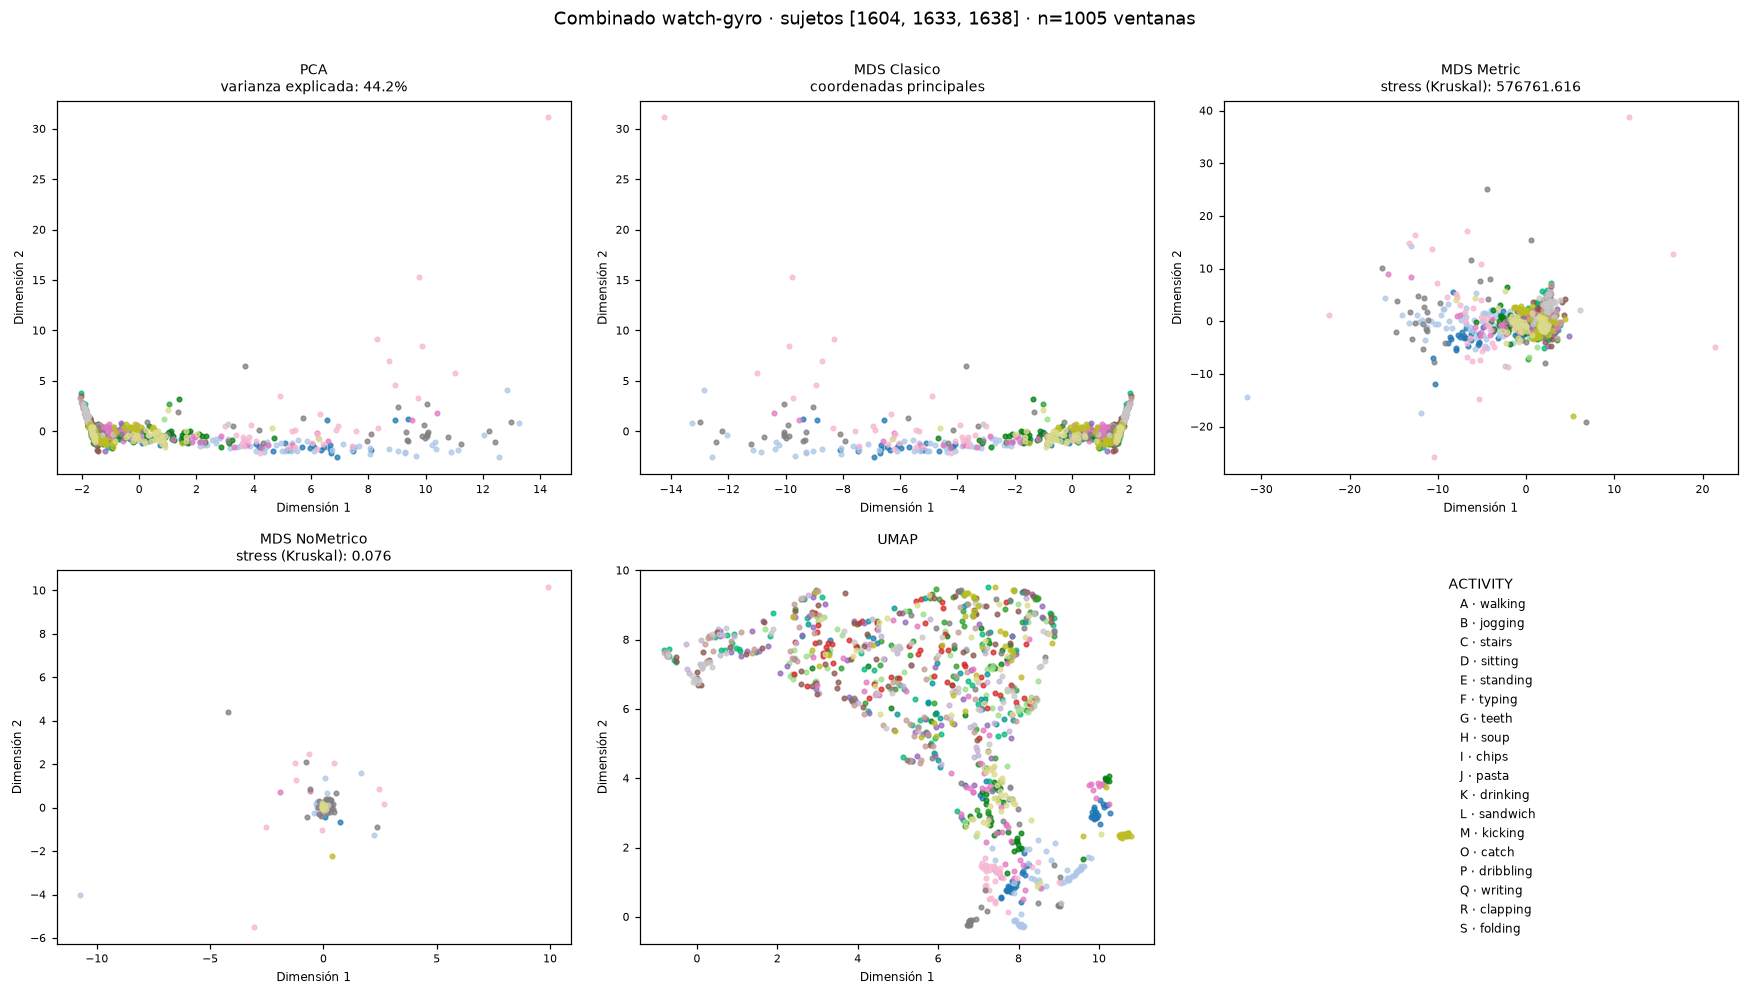

[OK] combinado watch-gyro (1005 ventanas)


In [7]:
# ============================================================================
# 6. Escenario B: combinación de los 3 sujetos por caso (4 figuras)
# ============================================================================
combinado = {}
for (dispositivo, sensor) in CASOS:
    df = pd.concat([matrices[(dispositivo, sensor)][s]
                    for s in SUJETOS], ignore_index=True)
    combinado[(dispositivo, sensor)] = df

    X_est = StandardScaler().fit_transform(df[BINS].values)
    y_act = df["ACTIVITY"].to_numpy()

    fig, axs = plt.subplots(2, 3, figsize=(16, 9))
    graficar_caso(X_est, y_act, f"{dispositivo}-{sensor} (combinado)",
                  TECNICAS, axs.ravel())
    fig.suptitle(f"Combinado {dispositivo}-{sensor} · sujetos {SUJETOS} "
                 f"· n={len(df)} ventanas", fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()
    print(f"[OK] combinado {dispositivo}-{sensor} ({len(df)} ventanas)")


In [8]:
# ============================================================================
# 7. Silueta por actividad y por técnica (casos combinados)
# ============================================================================

resumen = []
for (dispositivo, sensor), df in combinado.items():
    X_est = StandardScaler().fit_transform(df[BINS].values)
    y_act = df["ACTIVITY"].to_numpy()
    print("=" * 72)
    print(f"Caso combinado: {dispositivo}-{sensor}  (n = {len(df)})")
    por_act = None
    for nombre, fn in TECNICAS.items():
        emb, _ = fn(X_est)
        sil = silhouette_samples(emb, y_act)
        sdf = pd.DataFrame({"act": y_act, "sil": sil}).groupby("act")["sil"].mean()
        resumen.append((dispositivo, sensor, nombre, sil.mean()))
        top = sdf.sort_values(ascending=False).head(3)
        bot = sdf.sort_values().head(3)
        print(f"  {nombre:<13} sil_global={sil.mean():+.3f} | mejores: " +
              ", ".join(f"{a}={v:+.3f}" for a, v in top.items()) +
              " | peores: " + ", ".join(f"{a}={v:+.3f}" for a, v in bot.items()))
        por_act = sdf if por_act is None else por_act.add(sdf, fill_value=0)
    por_act = por_act / len(TECNICAS)
    orden = por_act.sort_values(ascending=False)
    print("  [Promedio entre técnicas] Mejor diferenciadas:", 
          ", ".join(f"{a}({ACT_NAMES[a]})" for a in orden.index[:3]))
    print("                            Peor (superpuestas):",
          ", ".join(f"{a}({ACT_NAMES[a]})" for a in orden.index[-3:]))

tab = pd.DataFrame(resumen, columns=["dispositivo", "sensor", "tecnica", "silueta_global"])
print("\n== Silueta media de cada técnica (promedio de los 4 casos combinados) ==")
print(tab.groupby("tecnica")["silueta_global"].mean().sort_values(ascending=False).round(3))

Caso combinado: phone-accel  (n = 1074)
  PCA           sil_global=-0.266 | mejores: S=+0.074, E=-0.046, O=-0.047 | peores: A=-0.457, P=-0.430, M=-0.370
  MDS Clasico   sil_global=-0.266 | mejores: S=+0.074, E=-0.046, O=-0.047 | peores: A=-0.457, P=-0.430, M=-0.370
  MDS Metric    sil_global=-0.191 | mejores: R=+0.236, O=+0.169, S=-0.022 | peores: A=-0.405, P=-0.361, C=-0.328
  MDS NoMetrico sil_global=-0.269 | mejores: O=+0.223, S=+0.019, H=+0.008 | peores: B=-0.611, P=-0.582, A=-0.581
  UMAP          sil_global=-0.240 | mejores: B=+0.144, A=+0.017, M=-0.043 | peores: S=-0.456, J=-0.431, I=-0.428
  [Promedio entre técnicas] Mejor diferenciadas: O(catch), S(folding), E(standing)
                            Peor (superpuestas): D(sitting), A(walking), P(dribbling)
Caso combinado: phone-gyro  (n = 965)
  PCA           sil_global=-0.305 | mejores: G=+0.229, B=-0.089, I=-0.163 | peores: P=-0.616, S=-0.509, R=-0.472
  MDS Clasico   sil_global=-0.305 | mejores: G=+0.229, B=-0.089, I=-0.163 |